# Coupled 2D Hydrogeophysical Modeling
**PyHydroGeophysiX · PyGIMLi · Flopy MODFLOW 6**

Test sintetico 2D accoppiato:
- **Cella 1** – Parsing dati reali → `el_pos` (48 elettrodi)
- **Cella 2** – Mesh geofisica PyGIMLi (Zona Vadosa marker=1, Substrato+Padding marker=2)
- **Cella 3** – Griglia MODFLOW 2005 con offset datum elettrodi/tensiometri
- **Cella 4** – Funzioni petrofisiche: Van Genuchten + Archie (h → θ → ρ_b)

Cross-check quote: max Dz = 0.0050 m  (soglia < 0.5 m)
OK  Quote coerenti tra i due file.

  Parametro                        Valore
  ----------------------------------------------------
  Numero elettrodi                 48
  Lunghezza profilo                56.40 m
  Spaziatura media                 1.20 m
  Quota min (Pt48)                 675.940 m a.s.l.
  Quota max (Pt1)                  686.170 m a.s.l.
  Dislivello totale                10.230 m

Prime 5  : [(0.0, 686.17), (1.2, 686.0), (2.4, 685.88), (3.6, 685.67), (4.8, 685.57)]
Ultime 5 : [(51.6, 676.86), (52.8, 676.58), (54.0, 676.31), (55.2, 676.16), (56.4, 675.94)]


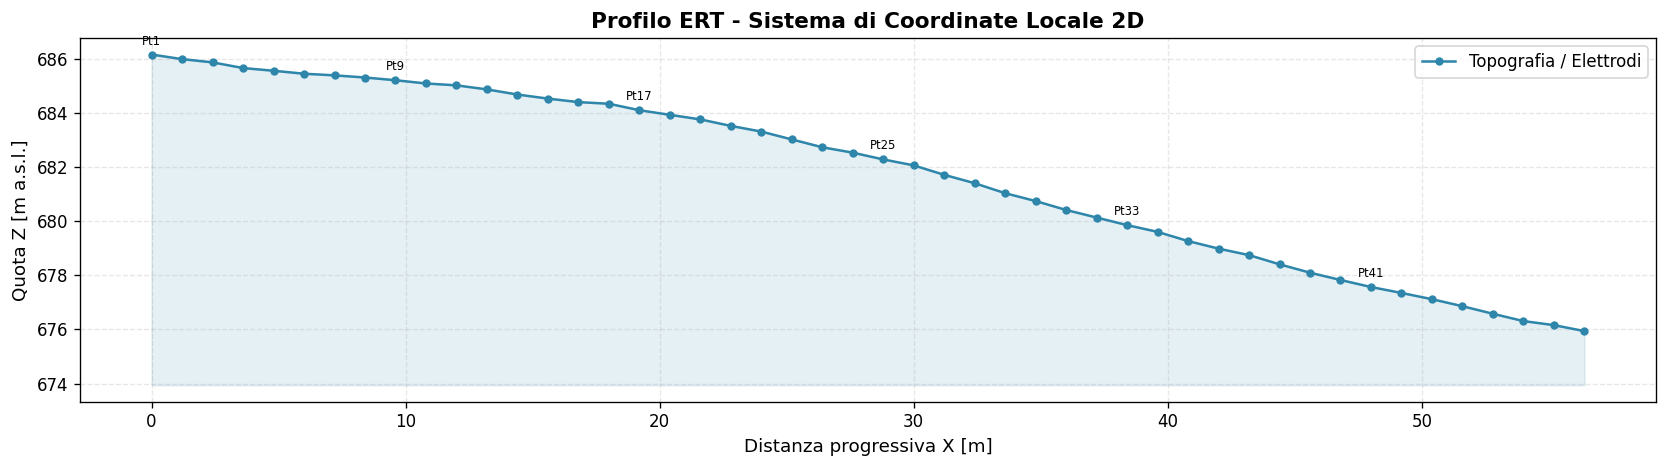


OK  el_pos costruito: 48 elettrodi - pronto per Cella 2


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 1 – Caricamento Dati e Coordinate Locali (Data Parsing)
# Input : electr_coord.csv (GPS WGS84) + 08topog_TL.txt (profilo locale X,Z)
# Output: el_pos = [(x [m], z [m a.s.l.]), ...]  – 48 elettrodi
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Directory di input ────────────────────────────────────────────────────
INPUT_DIR = Path(
    'C:/Users/luigi/git/github.com/luigimartinoisio-blip/PyHydroGeophysiX/Position'
)

# ── 1. Lettura 08topog_TL.txt ─────────────────────────────────────────────
# Formato: #,X,Y,Z,Depth  (la prima riga è l'header commentata con '#')
# X = distanza progressiva [m] in sistema locale (0–56.4 m, passo 1.2 m)
# Z = quota altimetrica assoluta [m a.s.l.]
topog = pd.read_csv(
    INPUT_DIR / '08topog_TL.txt',
    comment='#',
    header=None,
    names=['id', 'X_local', 'Y', 'Z_abs', 'Depth'],
    sep=',',
    skipinitialspace=True,
)
topog = topog.dropna(how='all').reset_index(drop=True)
topog = topog.astype({'X_local': float, 'Z_abs': float})

# ── 2. Lettura electr_coord.csv ───────────────────────────────────────────
# Formato: Nome punto, Latitudine, Longitudine, Altezza ellisoidica
# Ruolo  : verifica incrociata della quota (h ellissoidica ≈ Z topografica)
elec_gps = pd.read_csv(INPUT_DIR / 'electr_coord.csv', skipinitialspace=True)
elec_gps.columns = elec_gps.columns.str.strip()

# ── 3. Cross-check quote (soglia 0.5 m) ──────────────────────────────────
z_topog = topog['Z_abs'].values.astype(float)
z_gps   = elec_gps['Altezza ellisoidica'].values.astype(float)
delta_z = np.abs(z_topog - z_gps)
print('Cross-check quote: max Dz = {:.4f} m  (soglia < 0.5 m)'.format(delta_z.max()))
if delta_z.max() >= 0.5:
    raise ValueError('Incoerenza topografia/GPS: max Dz = {:.3f} m'.format(delta_z.max()))
print('OK  Quote coerenti tra i due file.')

# ── 4. Costruzione el_pos in coordinate locale 2D ─────────────────────────
# X = distanza progressiva dal primo elettrodo (Pt1 → X = 0)
# Z = quota altimetrica assoluta [m a.s.l.] → LIMITE SUPERIORE del dominio
x_profile = topog['X_local'].values.astype(float)
z_abs     = topog['Z_abs'].values.astype(float)

if len(x_profile) != 48:
    raise ValueError('Attesi 48 elettrodi, trovati {}'.format(len(x_profile)))

el_pos = list(zip(x_profile.tolist(), z_abs.tolist()))   # [(x1,z1), ..., (x48,z48)]

# ── 5. Riepilogo ──────────────────────────────────────────────────────────
spacing = float(np.diff(x_profile).mean())
rows = [
    ('Numero elettrodi',  str(len(el_pos))),
    ('Lunghezza profilo', '{:.2f} m'.format(x_profile[-1] - x_profile[0])),
    ('Spaziatura media',  '{:.2f} m'.format(spacing)),
    ('Quota min (Pt48)',  '{:.3f} m a.s.l.'.format(z_abs.min())),
    ('Quota max (Pt1)',   '{:.3f} m a.s.l.'.format(z_abs.max())),
    ('Dislivello totale', '{:.3f} m'.format(z_abs.max() - z_abs.min())),
]
print()
print('  {:<32} {}'.format('Parametro', 'Valore'))
print('  ' + '-' * 52)
for lbl, val in rows:
    print('  {:<32} {}'.format(lbl, val))
print()
print('Prime 5  :', el_pos[:5])
print('Ultime 5 :', el_pos[-5:])

# ── 6. Plot profilo topografico ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4), dpi=120)
xs, zs  = zip(*el_pos)
ax.plot(xs, zs, 'o-', ms=4, lw=1.5, color='#2E86AB', label='Topografia / Elettrodi')
ax.fill_between(xs, min(zs) - 2, zs, alpha=0.12, color='#2E86AB')
for i in range(0, len(xs), 8):
    ax.annotate('Pt{}'.format(i + 1), (xs[i], zs[i]),
                textcoords='offset points', xytext=(0, 6), ha='center', fontsize=7)
ax.set_xlabel('Distanza progressiva X [m]', fontsize=11)
ax.set_ylabel('Quota Z [m a.s.l.]', fontsize=11)
ax.set_title('Profilo ERT - Sistema di Coordinate Locale 2D',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
print('\nOK  el_pos costruito: {} elettrodi - pronto per Cella 2'.format(len(el_pos)))

Dominio  : X=[-15.0, 71.4] m | Z=[655.94, 686.17] m a.s.l.
Zona vadosa: X=[0.0, 56.4] m | spessore 4.0 m

Generazione mesh in corso (quality=34, smooth=True) ...

OK  Mesh generata:
   Nodi totali        : 49069
   Celle totali       : 96967

   [Zona Vadosa  marker=1  (X=0-56.4 m, 0-4 m depth)]
   Celle              : 88224
   Dim. max caratt.   : 0.1167 m  (limite ~0.10 m)
   Dim. media caratt. : 0.0702 m

   [Substrato + Padding  marker=2]
   Celle              : 8743
   Dim. max caratt.   : 2.0737 m
   Dim. media caratt. : 0.4297 m

OK  Raffinamento zona vadosa CONFORME (dim.max 0.1167 m)


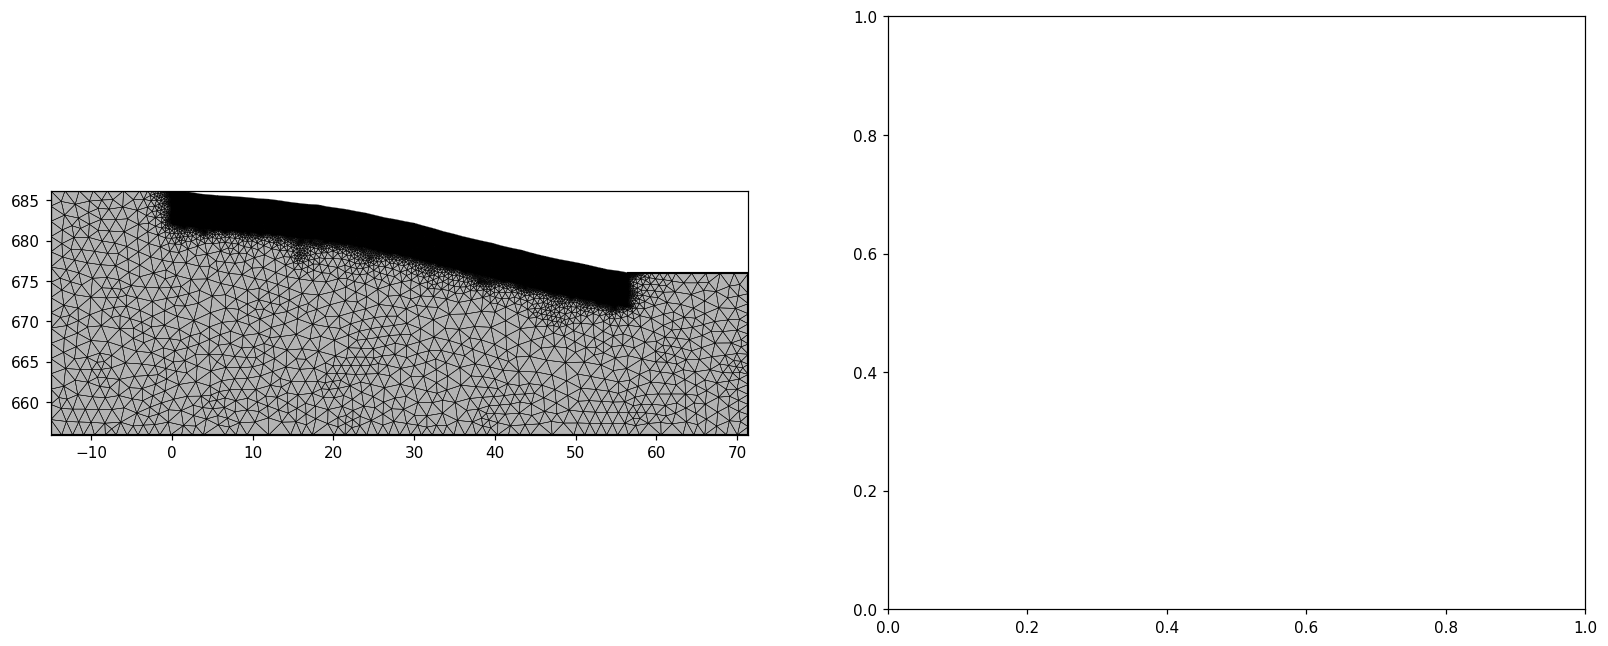

c:\Users\luigi\git\github.com\luigimartinoisio-blip\PyHydroGeophysiX\.venv\Lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1980x770 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)
c:\Users\luigi\git\github.com\luigimartinoisio-blip\PyHydroGeophysiX\.venv\Lib\site-packages\pygimli\viewer\mpl\utils.py:164: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  ax.figure.tight_layout()


<Figure size 640x480 with 0 Axes>


OK  48 posizioni elettrodo pronte - mesh pronta per forward ERT


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 2 – Generazione della Mesh Geofisica (PyGIMLi)
#
# Architettura a due regioni:
#   marker=1  Zona Vadosa  (X=0-56.4 m, profondita' 0-4 m)  area<=0.005 m^2
#   marker=2  Substrato + Padding laterale                    area<=2.0   m^2
#
# Triangle crea smooth grading automatico tra le due regioni.
# quality=34 evita triangoli distorti nella zona di transizione.
# =══════════════════════════════════════════════════════════════════════════
import numpy as np
import pygimli as pg
import pygimli.meshtools as mt
import matplotlib.pyplot as plt

# ── Parametri geometrici ──────────────────────────────────────────────────
x_arr = np.array([p[0] for p in el_pos])
z_arr = np.array([p[1] for p in el_pos])

LATERAL_EXT    = 15.0   # [m] padding laterale oltre il profilo
DEPTH_TOTAL    = 20.0   # [m] profondita' max sotto z_min degli elettrodi
VADOSA_DEPTH   =  4.0   # [m] spessore zona vadosa idrogeologicamente attiva
# Area max vadosa: sqrt(2 * 0.005) = 0.10 m → dim. caratteristica <= 0.10 m
VADOSA_AREA    = 0.005  # [m^2]
SUBSTRATE_AREA = 2.0    # [m^2] substrato + padding (computazionalmente leggero)

z_min_surf = z_arr.min()
z_max_surf = z_arr.max()
z_bottom   = z_min_surf - DEPTH_TOTAL
x_min      = x_arr[0]  - LATERAL_EXT
x_max      = x_arr[-1] + LATERAL_EXT

print('Dominio  : X=[{:.1f}, {:.1f}] m | Z=[{:.2f}, {:.2f}] m a.s.l.'.format(
    x_min, x_max, z_bottom, z_max_surf))
print('Zona vadosa: X=[{:.1f}, {:.1f}] m | spessore {:.1f} m'.format(
    x_arr[0], x_arr[-1], VADOSA_DEPTH))

# ── 1. PLC Mondo intero (marker=2 – substrato + padding laterale) ─────────
# Confine superiore: topografia + padding piatto
# Confine inferiore: piano orizzontale a z_bottom
boundary_pts = (
    [[x_min, float(z_arr[0])]] +
    [[float(x), float(z)] for x, z in zip(x_arr, z_arr)] +
    [[x_max, float(z_arr[-1])],
     [x_max, z_bottom],
     [x_min, z_bottom]]
)
world_plc = mt.createPolygon(
    boundary_pts, isClosed=True, marker=2, area=SUBSTRATE_AREA
)

# ── 2. PLC Zona Vadosa (marker=1 – X=0..56.4 m, depth 0..4 m) ────────────
# Top: topografia esatta degli elettrodi (senza padding laterale)
# Base: topografia - VADOSA_DEPTH (parallela punta per punta alla topografia)
# Lati: segmenti verticali in X=x_arr[0] e X=x_arr[-1]
vadosa_top = [[float(x), float(z)] for x, z in zip(x_arr, z_arr)]
vadosa_bot = [[float(x), float(z) - VADOSA_DEPTH]
              for x, z in zip(x_arr[::-1], z_arr[::-1])]
vadosa_plc = mt.createPolygon(
    vadosa_top + vadosa_bot, isClosed=True, marker=1, area=VADOSA_AREA
)

# ── 3. Fusione PLCs e aggiunta nodi elettrodo ─────────────────────────────
full_plc = mt.mergePLC([world_plc, vadosa_plc])

# Elettrodi come nodi espliciti di superficie + sub-surface anchor
for xi, zi in el_pos:
    full_plc.createNode([float(xi), float(zi)])
    full_plc.createNode([float(xi), float(zi) - 0.01])   # stabilita' FEM

# Nodi ausiliari alla base della zona vadosa ogni 3 elettrodi:
# guidano il smooth grading dalla regione densa a quella sparsa
for xi, zi in list(zip(x_arr, z_arr))[::3]:
    full_plc.createNode([float(xi), float(zi) - VADOSA_DEPTH])

# ── 4. Generazione mesh ───────────────────────────────────────────────────
# quality=34 → angolo minimo piu' stringente per ridurre triangoli distorti
# nella zona di transizione tra le due regioni (smooth grading automatico)
print('\nGenerazione mesh in corso (quality=34, smooth=True) ...')
mesh = mt.createMesh(full_plc, quality=34, smooth=True)

# ── 5. Statistiche per regione (marker) ──────────────────────────────────
cell_areas   = np.array([c.size() for c in mesh.cells()])
cell_markers = np.array([c.marker() for c in mesh.cells()])
char_len     = np.sqrt(2.0 * cell_areas)

vadosa_mask = cell_markers == 1
substr_mask = cell_markers == 2
cl_vadosa   = char_len[vadosa_mask]
cl_substr   = char_len[substr_mask]

print('\nOK  Mesh generata:')
print('   Nodi totali        : {}'.format(mesh.nodeCount()))
print('   Celle totali       : {}'.format(mesh.cellCount()))
print()
print('   [Zona Vadosa  marker=1  (X=0-56.4 m, 0-{:.0f} m depth)]'.format(VADOSA_DEPTH))
print('   Celle              : {}'.format(vadosa_mask.sum()))
print('   Dim. max caratt.   : {:.4f} m  (limite ~0.10 m)'.format(cl_vadosa.max()))
print('   Dim. media caratt. : {:.4f} m'.format(cl_vadosa.mean()))
print()
print('   [Substrato + Padding  marker=2]')
print('   Celle              : {}'.format(substr_mask.sum()))
print('   Dim. max caratt.   : {:.4f} m'.format(cl_substr.max()))
print('   Dim. media caratt. : {:.4f} m'.format(cl_substr.mean()))

if cl_vadosa.max() <= 0.12:
    print('\nOK  Raffinamento zona vadosa CONFORME (dim.max {:.4f} m)'.format(cl_vadosa.max()))
else:
    print('\nATT Raffinamento FUORI LIMITE ({:.4f} m) - ridurre VADOSA_AREA'.format(
        cl_vadosa.max()))

# ── 6. Visualizzazione ────────────────────────────────────────────────────
markers_arr = np.array([c.marker() for c in mesh.cells()], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=110)

# — Vista completa: celle colorate per marker di regione —
pg.show(mesh, data=markers_arr, ax=axes[0], showMesh=True,
        cMap='Set2', colorBar=True, label='Region marker')
axes[0].plot(x_arr, z_arr, 'rv', ms=5, zorder=10, label='Elettrodi (48)')
axes[0].plot(x_arr, z_arr - VADOSA_DEPTH, 'b--', lw=1.5,
             label='Base zona vadosa (-4 m)')
axes[0].set_title(
    'Mesh Geofisica - Vista Completa\n(marker 1=Vadosa  marker 2=Substrato+Padding)',
    fontsize=11, fontweight='bold')
axes[0].set_xlabel('X [m]')
axes[0].set_ylabel('Z [m a.s.l.]')
axes[0].legend(fontsize=8)

# — Zoom sulla zona vadosa (elettrodi 12-24) —
j0, j1 = 11, 24
pg.show(mesh, data=markers_arr, ax=axes[1], showMesh=True,
        cMap='Set2', colorBar=False)
axes[1].plot(x_arr, z_arr, 'rv', ms=5, zorder=10, label='Elettrodi')
axes[1].plot(x_arr, z_arr - VADOSA_DEPTH, 'b--', lw=1.5,
             label='Base vadosa (-{:.0f} m)'.format(VADOSA_DEPTH))
axes[1].set_xlim(x_arr[j0] - 0.5, x_arr[j1] + 0.5)
axes[1].set_ylim(z_arr[j0:j1+1].min() - VADOSA_DEPTH - 0.5,
                 z_arr[j0:j1+1].max() + 0.3)
axes[1].set_title(
    'Zoom Zona Vadosa (0-{:.0f} m depth)\ndim.max = {:.3f} m | celle = {}'.format(
        VADOSA_DEPTH, cl_vadosa.max(), vadosa_mask.sum()),
    fontsize=11, fontweight='bold')
axes[1].set_xlabel('X [m]')
axes[1].set_ylabel('Z [m a.s.l.]')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

sensor_arr = np.array([[float(x), float(z)] for x, z in el_pos])
print('\nOK  {} posizioni elettrodo pronte - mesh pronta per forward ERT'.format(len(el_pos)))

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 3 – Griglia MODFLOW 2D (flopy.modflow.ModflowDis)
#           con Z-offset chirurgico e localizzazione sensori tensiometrici
# ═══════════════════════════════════════════════════════════════════════════
#
# GEOMETRIA CELLE:
# ───────────────────────────────────────────────────────────────────────────
# Gli elettrodi (48) sono i BORDI delle colonne.
# ncol = 48 - 1 = 47 celle. Il centro X della cella j è la media di X[j] e X[j+1].
# Il top della cella j è la media delle quote Z degli elettrodi ai suoi bordi.
#
# Z-OFFSET CHIRURGICO (5 layer):
# ───────────────────────────────────────────────────────────────────────────
# Vero Piano Campagna (TGS)           z_TGS
# Elettrodi (piantati -10 cm dal TGS) z_el = z_TGS - 0.10
# TOP modello MODFLOW                 top_elev = z_el  (le 47 medie)
#
# Basi layer (offset dal top_elev di ogni cella):
#   L1 base: top_elev - 0.1   → centro L1 a -0.05 m dal top
#   L2 base: top_elev - 0.3   → centro L2 a -0.20 m dal top
#                                  → -0.20 + (-0.10) = -0.30 m dal TGS  ✓ Tens.1
#   L3 base: top_elev - 0.5   → centro L3 a -0.40 m dal top
#   L4 base: top_elev - 0.9   → centro L4 a -0.70 m dal top
#                                  → -0.70 + (-0.10) = -0.80 m dal TGS  ✓ Tens.2
#   L5 base: top_elev - 4.0   → copre l'intera zona vadosa attiva
# ───────────────────────────────────────────────────────────────────────────
import numpy as np
import flopy
import matplotlib.pyplot as plt
from pathlib import Path

# ── 1. Arrays da Cella 1 ─────────────────────────────────────────────────
x_arr = np.array([p[0] for p in el_pos])   # 48 posizioni X degli elettrodi [m]
z_arr = np.array([p[1] for p in el_pos])   # 48 quote Z degli elettrodi [m a.s.l.]

assert len(x_arr) == 48, 'Attesi 48 elettrodi, trovati {}'.format(len(x_arr))

# ── 2. Griglia orizzontale: ncol = 47 celle (elettrodi = bordi) ───────────
NCOL = len(x_arr) - 1                              # 47
NROW = 1                                            # 2D pseudo-profilo
NLAY = 5                                            # 5 layer chirurgici

delr = np.full(NCOL, 1.2)                          # larghezza cella = 1.2 m uniforme
delc = np.array([1.0])                             # larghezza riga (pseudo-2D)

# Centri X delle celle (per localizzazione sensori)
x_col_center = (x_arr[:-1] + x_arr[1:]) / 2.0     # shape (47,)

# ── 3. Topografia celle: media delle quote Z agli elettrodi bordo ─────────
top_elev = (z_arr[:-1] + z_arr[1:]) / 2.0         # shape (47,)  [m a.s.l.]

print('Griglia 2D: NLAY={}, NROW={}, NCOL={}'.format(NLAY, NROW, NCOL))
print('delr = {:.2f} m (uniforme)'.format(delr[0]))
print('top_elev : min={:.3f} m  max={:.3f} m  range={:.3f} m'.format(
    top_elev.min(), top_elev.max(), top_elev.max() - top_elev.min()))

# ── 4. Basi layer (Z-offset chirurgico) ──────────────────────────────────
# Tutti gli offset sono RELATIVI a top_elev di ogni cella (topografia variabile)
# Shape botm: (NLAY, NROW, NCOL) = (5, 1, 47)
OFFSETS = np.array([0.1, 0.3, 0.5, 0.9, 4.0])   # profondita' basi layer [m]

botm = np.zeros((NLAY, NROW, NCOL))
for k, dz in enumerate(OFFSETS):
    botm[k, 0, :] = top_elev - dz                 # quota assoluta base layer k

# Top array per MODFLOW DIS (shape NROW x NCOL)
top_2d = top_elev.reshape(NROW, NCOL)

# ── 5. Verifica centri cella (quote assolute) ─────────────────────────────
# Centro L1: (top_elev + base_L1) / 2 = top_elev - 0.05  → -0.05 m dal top
# Centro L2: (base_L1 + base_L2) / 2 = top_elev - 0.20  → -0.20 m dal top = -0.30 m TGS
# Centro L4: (base_L3 + base_L4) / 2 = top_elev - 0.70  → -0.70 m dal top = -0.80 m TGS
ctr_abs = np.zeros((NLAY, NCOL))
for k in range(NLAY):
    top_k = top_elev if k == 0 else botm[k-1, 0, :]
    bot_k = botm[k, 0, :]
    ctr_abs[k, :] = (top_k + bot_k) / 2.0

# Offset dal top_elev (dovrebbe essere costante columnwise per verifica)
ctr_offset = top_elev - ctr_abs[1, :]   # Layer 2: atteso ~0.20 m
ctr_offset_L4 = top_elev - ctr_abs[3, :]  # Layer 4: atteso ~0.70 m
print('\nVerifica centri cella (valori medi su 47 colonne):')
print('  Centro L2 a {:.4f} m sotto top_elev  → {:.4f} m sotto TGS (target -0.30 m)'.format(
    ctr_offset.mean(), ctr_offset.mean() + 0.10))
print('  Centro L4 a {:.4f} m sotto top_elev  → {:.4f} m sotto TGS (target -0.80 m)'.format(
    ctr_offset_L4.mean(), ctr_offset_L4.mean() + 0.10))

# ── 6. Costruzione modello flopy.modflow (MODFLOW 2005) ───────────────────
MODEL_WS = Path(
    'C:/Users/luigi/git/github.com/luigimartinoisio-blip/PyHydroGeophysiX/mf2005_coupled'
)
MODEL_WS.mkdir(parents=True, exist_ok=True)
MODEL_NAME = 'coupled_hydrogeo_dis'

model = flopy.modflow.Modflow(
    modelname = MODEL_NAME,
    exe_name  = 'mf2005',        # deve essere nel PATH; non eseguito qui
    model_ws  = str(MODEL_WS),
    version   = 'mf2005',
)

# DIS – discretizzazione spazio-temporale
dis = flopy.modflow.ModflowDis(
    model,
    nlay = NLAY,
    nrow = NROW,
    ncol = NCOL,
    delr = delr,
    delc = delc,
    top  = top_2d,
    botm = botm,
    nper = 1,
    perlen   = [1.0],
    nstp     = [1],
    steady   = [True],
    itmuni   = 4,    # unità tempo: giorni
    lenuni   = 2,    # unità lunghezza: metri
)

print('\nOK  Pacchetto DIS creato:')
print('   NLAY={}, NROW={}, NCOL={}'.format(dis.nlay, dis.nrow, dis.ncol))
print('   Extent X: [{:.2f}, {:.2f}] m'.format(
    float(x_col_center[0]) - 0.6, float(x_col_center[-1]) + 0.6))
print('   Extent Z: [{:.3f}, {:.3f}] m a.s.l.'.format(
    float(botm[-1, 0, :].min()), float(top_elev.max())))

# ── 7. Centri cella (quote assolute) per Layer 2 e Layer 4 ───────────────
# ModflowDis non espone zcellcenters; usiamo ctr_abs calcolato al passo 5.
# ctr_abs[k, j] = (top_k[j] + bot_k[j]) / 2  →  shape (NLAY, NCOL)

# Layer 2 → indice 1;  Layer 4 → indice 3
z_L2 = ctr_abs[1, :]   # shape (47,)   [m a.s.l.]
z_L4 = ctr_abs[3, :]   # shape (47,)   [m a.s.l.]

# ── 8. Localizzazione sensori a X = 8 m, 31 m, 51 m ──────────────────────
SENS_X_TARGETS = [8.0, 31.0, 51.0]   # [m] posizioni nominali sensori

print('\n' + '=' * 72)
print('  REPORT SENSORI TENSIOMETRICI – POSIZIONI E QUOTE NODALI')
print('  (Layer 2 ≈ -30 cm TGS  |  Layer 4 ≈ -80 cm TGS)')
print('=' * 72)
print('  {:<10}{:<10}{:<18}{:<22}{:<22}'.format(
    'X target', 'col_idx', 'X cella [m]', 'Z nodo L2 [m asl]', 'Z nodo L4 [m asl]'))
print('  ' + '-' * 70)

for x_target in SENS_X_TARGETS:
    # Indice di colonna più vicino al target
    col_idx = int(np.argmin(np.abs(x_col_center - x_target)))
    x_real  = float(x_col_center[col_idx])
    z_sens2 = float(z_L2[col_idx])
    z_sens4 = float(z_L4[col_idx])
    print('  {:<10.1f}{:<10d}{:<18.4f}{:<22.4f}{:<22.4f}'.format(
        x_target, col_idx, x_real, z_sens2, z_sens4))

print('=' * 72)
print()
print('Nota: Z nodo = quota assoluta centro-cella [m a.s.l.].')
print('      L2 centro a -0.20 m dal top modello = -0.30 m dal TGS.')
print('      L4 centro a -0.70 m dal top modello = -0.80 m dal TGS.')
print()
print('OK  Cella 3 completata. Modello MODFLOW 2005 pronto (non eseguito).')
print('    Workspace: {}'.format(MODEL_WS))

Griglia 2D: NLAY=5, NROW=1, NCOL=47
delr = 1.20 m (uniforme)
top_elev : min=676.050 m  max=686.085 m  range=10.035 m

Verifica centri cella (valori medi su 47 colonne):
  Centro L2 a 0.2000 m sotto top_elev  → 0.3000 m sotto TGS (target -0.30 m)
  Centro L4 a 0.7000 m sotto top_elev  → 0.8000 m sotto TGS (target -0.80 m)

OK  Pacchetto DIS creato:
   NLAY=5, NROW=1, NCOL=47
   Extent X: [0.00, 56.40] m
   Extent Z: [672.050, 686.085] m a.s.l.

  REPORT SENSORI TENSIOMETRICI – POSIZIONI E QUOTE NODALI
  (Layer 2 ≈ -30 cm TGS  |  Layer 4 ≈ -80 cm TGS)
  X target  col_idx   X cella [m]       Z nodo L2 [m asl]     Z nodo L4 [m asl]     
  ----------------------------------------------------------------------
  8.0       6         7.8000            685.1600              684.6600              
  31.0      25        30.6000           681.6950              681.1950              
  51.0      42        51.0000           676.7900              676.2900              

Nota: Z nodo = quota assoluta 

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 4 - Il Ponte Petrofisico (Switch Letteratura vs Laboratorio)
# Obiettivo: Calcolare rho_wet e rho_dry scegliendo il set di parametri
# ═══════════════════════════════════════════════════════════════════════════

# ── 0. L'INTERRUTTORE STRATEGICO ──────────────────────────────────────────
# Cambia questa stringa in 'LITERATURE' o 'LAB' per decidere la fisica
PETRO_MODE = 'LAB' 

print(f"--- INIZIALIZZAZIONE PETROFISICA: Modalità {PETRO_MODE} ---")

# ── 1. Definizione Funzioni ───────────────────────────────────────────────
def vg_theta(h, theta_s, theta_r, alpha, n):
    """Modello di Van Genuchten (Letteratura)"""
    h_suction = np.where(h < 0, np.abs(h), 0)
    m = 1.0 - (1.0 / n)
    return theta_r + (theta_s - theta_r) / (1.0 + (alpha * h_suction)**n)**m

def archie_rho(theta, a, m, rho_w):
    """Legge di Archie (Letteratura)"""
    return a * rho_w * (theta)**(-m)

def hyprop_resistivity(h, alpha, n, m, n_a, rho_sat):
    """Modello Normalizzato (Calibrazione Hyprop da Laboratorio)"""
    suction = np.where(h < 0, np.abs(h), 0.0)
    ec_norm = (1.0 + (alpha * suction)**n)**(-m * n_a)
    return rho_sat / ec_norm

# ── 2. Esecuzione Condizionale ────────────────────────────────────────────

if PETRO_MODE == 'LITERATURE':
    print("-> Utilizzo modello omogeneo (Limo Argilloso standard)")
    # Parametri generici in scala metrica
    p_vg = {'theta_s': 0.45, 'theta_r': 0.20, 'alpha': 1.5, 'n': 1.5}
    p_archie = {'a': 1.0, 'm': 2.0, 'rho_w': 15.0}
    
    # Calcolo su tutto il dominio
    theta_wet = vg_theta(h_wet, **p_vg)
    theta_dry = vg_theta(h_dry, **p_vg)
    rho_wet = archie_rho(theta_wet, **p_archie)
    rho_dry = archie_rho(theta_dry, **p_archie)

elif PETRO_MODE == 'LAB':
    print("-> Utilizzo modello eterogeneo (Dati reali Hyprop 2)")
    # Inizializzazione array vuoti
    rho_wet = np.zeros_like(h_wet)
    rho_dry = np.zeros_like(h_dry)
    
    # Parametri scalati in metri (Superficie: Layer 1-2)
    p_surf = {'alpha': 0.504, 'n': 1.239, 'm': 0.193, 'n_a': 3.460, 'rho_sat': 9.27}
    rho_wet[0:2, :] = hyprop_resistivity(h_wet[0:2, :], **p_surf)
    rho_dry[0:2, :] = hyprop_resistivity(h_dry[0:2, :], **p_surf)
    
    # Parametri scalati in metri (Profondità: Layer 3+)
    p_deep = {'alpha': 0.619, 'n': 1.236, 'm': 0.191, 'n_a': 5.068, 'rho_sat': 10.77}
    rho_wet[2:, :] = hyprop_resistivity(h_wet[2:, :], **p_deep)
    rho_dry[2:, :] = hyprop_resistivity(h_dry[2:, :], **p_deep)

else:
    raise ValueError("PETRO_MODE non valido. Scegli 'LITERATURE' o 'LAB'.")

print("-> Calcolo resistività completato.")

--- INIZIALIZZAZIONE PETROFISICA: Modalità LAB ---
-> Utilizzo modello eterogeneo (Dati reali Hyprop 2)


NameError: name 'h_wet' is not defined

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 5 – Il Motore Idrologico Transitorio (MODFLOW-NWT)
# Obiettivo: Simulare Inizializzazione, Pioggia Intensa e Asciugatura
# ═══════════════════════════════════════════════════════════════════════════
import flopy
import os
import numpy as np

workspace = os.path.join(os.getcwd(), 'mf2005_coupled')
if not os.path.exists(workspace):
    os.makedirs(workspace)

print("Inizializzazione del modello MODFLOW-NWT...")

# Usiamo la versione NWT, imbattibile per la zona non confinata
mf = flopy.modflow.Modflow("hydro_transient", version="mfnwt", exe_name="mfnwt", model_ws=workspace)

# ── 1. Geometria (Pacchetto DIS) ──────────────────────────────────────────
nlay = 5; nrow = 1; ncol = len(x_arr) - 1
delr = 1.2; delc = 1.0

top_elev = (z_arr[:-1] + z_arr[1:]) / 2
top_elev = top_elev.reshape((nrow, ncol))

botm = np.zeros((nlay, nrow, ncol))
botm[0, 0, :] = top_elev - 0.1
botm[1, 0, :] = top_elev - 0.3
botm[2, 0, :] = top_elev - 0.5
botm[3, 0, :] = top_elev - 0.9
botm[4, 0, :] = top_elev - 4.0

nper = 3
perlen = [1.0, 5.0, 10.0]
nstp = [1, 5, 10]
steady = [True, False, False]

dis = flopy.modflow.ModflowDis(mf, nlay=nlay, nrow=nrow, ncol=ncol, nper=nper,
                               delr=delr, delc=delc, top=top_elev, botm=botm,
                               perlen=perlen, nstp=nstp, steady=steady)

# ── 2. Condizioni Iniziali (Pacchetto BAS) ───────────────────────────────
ibound = np.ones((nlay, nrow, ncol), dtype=int)
# FIX FISICO: La falda parte parallelamente al terreno, 1 metro sotto.
strt = top_elev - 1.0  
bas = flopy.modflow.ModflowBas(mf, ibound=ibound, strt=strt)

# ── 3. Proprietà Idrauliche NWT (Pacchetto UPW) ──────────────────────────
hk = 0.5; vka = 0.05; sy = 0.15; ss = 1e-5
# UPW sostituisce LPF per gestire le celle asciutte senza disattivarle
upw = flopy.modflow.ModflowUpw(mf, laytyp=1, hk=hk, vka=vka, sy=sy, ss=ss)

# ── 4. Condizioni al Contorno (Pacchetto CHD) ────────────────────────────
# Valori assoluti scalati dinamicamente sulla topografia dei bordi
head_up = float(top_elev[0, 0] - 3.5)
head_down = float(top_elev[0, ncol-1] - 3.5)

chd_data = {}
for i in range(nper):
    chd_data[i] = [
        [4, 0, 0, head_up, head_up],
        [4, 0, ncol-1, head_down, head_down]
    ]
chd = flopy.modflow.ModflowChd(mf, stress_period_data=chd_data)

# ── 5. Ricarica Meteorica (Pacchetto RCH) ────────────────────────────────
rech_data = {0: 0.0, 1: 0.05, 2: 0.0}
rch = flopy.modflow.ModflowRch(mf, rech=rech_data)

# ── 6. Risolutore di Newton (Pacchetto NWT) ──────────────────────────────
nwt = flopy.modflow.ModflowNwt(mf, headtol=1e-3, fluxtol=1e-3, maxiterout=500)

# ── 7. Output Control (Pacchetto OC) ─────────────────────────────────────
spd = {}
for kper in range(nper):
    for kstp in range(nstp[kper]):
        spd[(kper, kstp)] = ['save head', 'save budget']
oc = flopy.modflow.ModflowOc(mf, stress_period_data=spd)

# ── 8. Esecuzione ────────────────────────────────────────────────────────
print("\nScrittura dei file di input per MODFLOW-NWT...")
mf.write_input()

print("Avvio della simulazione...")
success, buff = mf.run_model(silent=False)

if success:
    print("\nOK - Simulazione terminata con successo. Il motore ha calcolato la fisica.")
else:
    print("\nERRORE - MODFLOW non è riuscito a convergere.")

Inizializzazione del modello MODFLOW-NWT...

Scrittura dei file di input per MODFLOW-NWT...
Avvio della simulazione...
FloPy is using the following executable to run the model: ..\.venv\Scripts\mfnwt.exe

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: hydro_transient.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2026/04/26 11:56:04

 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     2    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     2    Time step:     2    Groundwater-Flow Eqn.
 Solving:  Stress period:     

C:\Users\luigi\AppData\Local\Temp\ipykernel_10452\1638912912.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


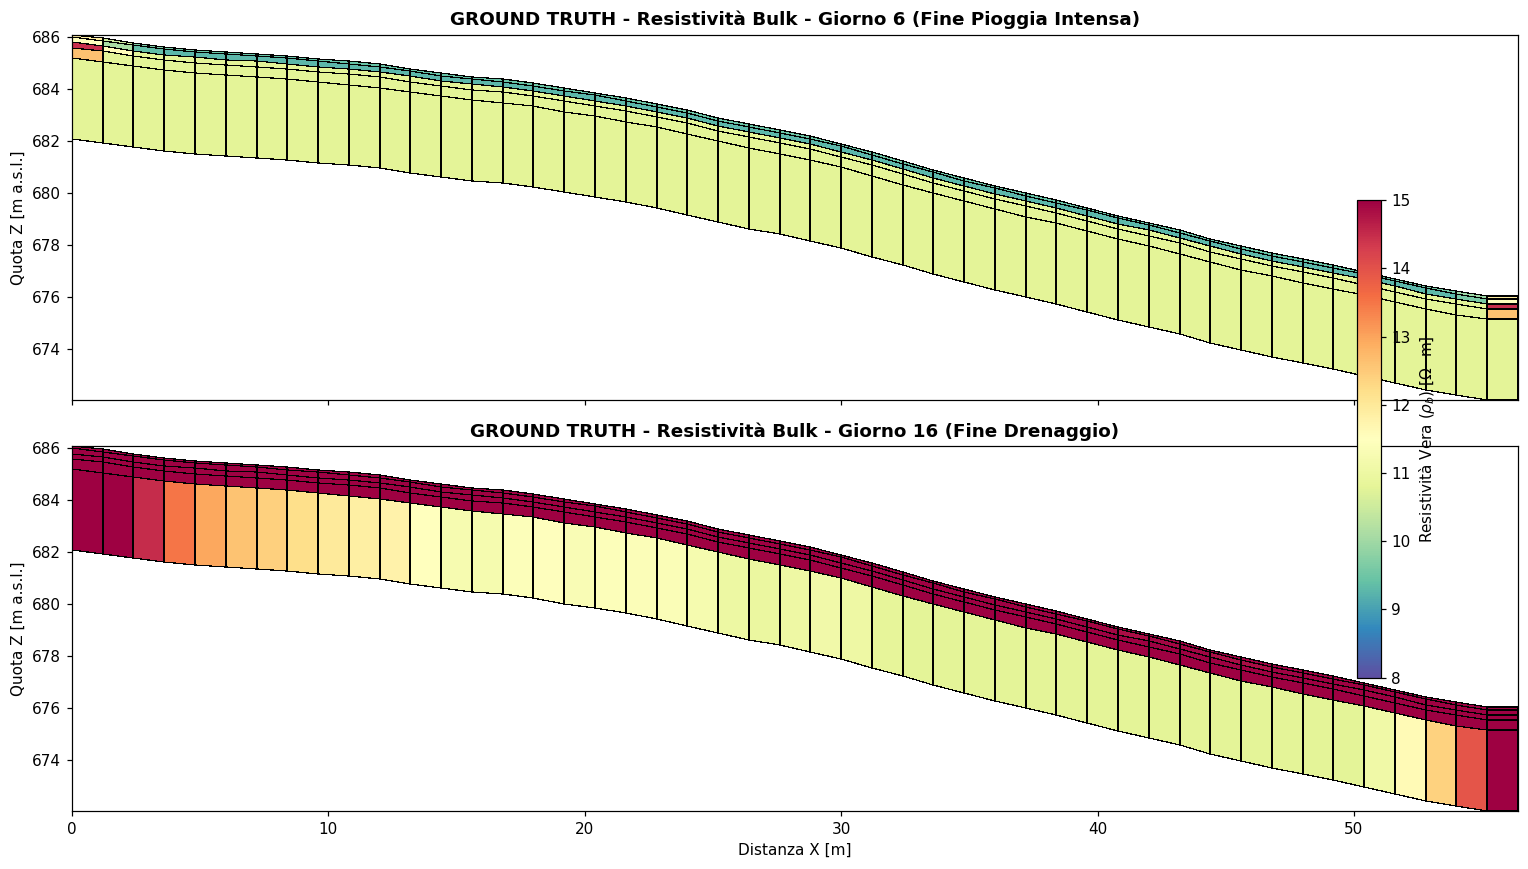

--- VERIFICA SENSORI (Ground Truth) ---
Colonna 6 (X = 7.2m):
  Layer 2 (-30cm) -> Wet: 9.27 ohm-m | Dry: 16.67 ohm-m
  Layer 4 (-80cm) -> Wet: 10.77 ohm-m | Dry: 25.08 ohm-m
Colonna 25 (X = 30.0m):
  Layer 2 (-30cm) -> Wet: 9.27 ohm-m | Dry: 15.80 ohm-m
  Layer 4 (-80cm) -> Wet: 10.77 ohm-m | Dry: 22.78 ohm-m
Colonna 42 (X = 50.4m):
  Layer 2 (-30cm) -> Wet: 9.27 ohm-m | Dry: 15.84 ohm-m
  Layer 4 (-80cm) -> Wet: 10.77 ohm-m | Dry: 22.89 ohm-m


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 6 – Estrazione, Petrofisica Sito-Specifico e Ground Truth 2D
# Obiettivo: Visualizzare la vera resistività del modello prima dell'inversione
# ═══════════════════════════════════════════════════════════════════════════
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import flopy

hds_file = os.path.join(workspace, 'hydro_transient.hds')
if not os.path.exists(hds_file):
    raise FileNotFoundError("File .hds non trovato. MODFLOW non ha salvato i risultati.")

# ── 1. Estrazione del Carico Idraulico (Head) ─────────────────────────────
headobj = flopy.utils.HeadFile(hds_file)

# Estraiamo i fotogrammi chiave (Giorno 6 e Giorno 16):
head_wet = headobj.get_data(kstpkper=(4, 1))[0, :, :]
head_dry = headobj.get_data(kstpkper=(9, 2))[0, :, :]

# ── 2. Calcolo delle Quote Z e della Suzione ──────────────────────────────
Z_centers = np.zeros((nlay, ncol))
Z_centers[0, :] = (top_elev[0, :] + botm[0, 0, :]) / 2.0
for i in range(1, nlay):
    Z_centers[i, :] = (botm[i-1, 0, :] + botm[i, 0, :]) / 2.0

h_wet = head_wet - Z_centers
h_dry = head_dry - Z_centers

# ── 3. Il Ponte Petrofisico SITO-SPECIFICO (Hyprop 2) ─────────────────────
def hyprop_resistivity(h, alpha, n, m, n_a, rho_sat):
    suction = np.where(h < 0, np.abs(h), 0.0)
    ec_norm = (1.0 + (alpha * suction)**n)**(-m * n_a)
    return rho_sat / ec_norm

rho_wet = np.zeros_like(h_wet)
rho_dry = np.zeros_like(h_dry)

# Parametri LAB per i layer superficiali (0-40cm) e profondi (>50cm)
p_surf = {'alpha': 0.504, 'n': 1.239, 'm': 0.193, 'n_a': 3.460, 'rho_sat': 9.27}
p_deep = {'alpha': 0.619, 'n': 1.236, 'm': 0.191, 'n_a': 5.068, 'rho_sat': 10.77}

# Applicazione stratificata
rho_wet[0:2, :] = hyprop_resistivity(h_wet[0:2, :], **p_surf)
rho_wet[2:, :] = hyprop_resistivity(h_wet[2:, :], **p_deep)

rho_dry[0:2, :] = hyprop_resistivity(h_dry[0:2, :], **p_surf)
rho_dry[2:, :] = hyprop_resistivity(h_dry[2:, :], **p_deep)

# ── 4. Costruzione della Griglia Visiva 2D ────────────────────────────────
X_edges = np.zeros((nlay + 1, ncol + 1))
Z_edges = np.zeros((nlay + 1, ncol + 1))

for i in range(nlay + 1):
    X_edges[i, :] = x_arr

Z_edges[0, :-1] = top_elev[0, :]
Z_edges[0, -1] = top_elev[0, -1]
for i in range(nlay):
    Z_edges[i+1, :-1] = botm[i, 0, :]
    Z_edges[i+1, -1] = botm[i, 0, -1]

# ── 5. Visualizzazione del Ground Truth ───────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), dpi=110, sharex=True, sharey=True)

# ATTENZIONE: La scala colori è stata drasticamente ristretta per mostrare
# la vera dinamica della tua argilla (Low Dynamic Range). 
cmap = 'Spectral_r' 
norm = colors.Normalize(vmin=8, vmax=15) 

mesh1 = axes[0].pcolormesh(X_edges, Z_edges, rho_wet, shading='flat', cmap=cmap, norm=norm, edgecolors='k', linewidth=0.1)
axes[0].set_title('GROUND TRUTH - Resistività Bulk - Giorno 6 (Fine Pioggia Intensa)', fontweight='bold')
axes[0].set_ylabel('Quota Z [m a.s.l.]')

mesh2 = axes[1].pcolormesh(X_edges, Z_edges, rho_dry, shading='flat', cmap=cmap, norm=norm, edgecolors='k', linewidth=0.1)
axes[1].set_title('GROUND TRUTH - Resistività Bulk - Giorno 16 (Fine Drenaggio)', fontweight='bold')
axes[1].set_xlabel('Distanza X [m]')
axes[1].set_ylabel('Quota Z [m a.s.l.]')

cbar = fig.colorbar(mesh2, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label(r'Resistività Vera ($\rho_b$) [$\Omega\cdot$m]')

plt.tight_layout()
plt.show()

print("--- VERIFICA SENSORI (Ground Truth) ---")
col_idxs = [6, 25, 42]
for c in col_idxs:
    print(f"Colonna {c} (X = {x_arr[c]:.1f}m):")
    print(f"  Layer 2 (-30cm) -> Wet: {rho_wet[1, c]:.2f} ohm-m | Dry: {rho_dry[1, c]:.2f} ohm-m")
    print(f"  Layer 4 (-80cm) -> Wet: {rho_wet[3, c]:.2f} ohm-m | Dry: {rho_dry[3, c]:.2f} ohm-m")

<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\s'
C:\Users\luigi\AppData\Local\Temp\ipykernel_10452\1438085729.py:42: SyntaxWarning: invalid escape sequence '\s'
  df_seq = pd.read_csv(file_path, skiprows=50, sep='\s+', names=['idx', 'A', 'B', 'M', 'N'])


1. Mapping dell'idrologia sulla mesh geofisica...
2. Caricamento sequenza reale e posizionamento elettrodi...
-> Sequenza reale caricata con successo: 1224 misure valide.
3. Iniezione di corrente e simulazione del rumore (3%)...


26/04/26 - 12:01:16 - pyGIMLi - INFO - Calculate geometric factors.
26/04/26 - 12:03:03 - pyGIMLi - INFO - Data error estimate (min:max)  0.030088318829494618 : 0.032314744900992266
26/04/26 - 12:04:44 - pyGIMLi - INFO - Data error estimate (min:max)  0.030045244256066604 : 0.03147216233898111


4. Generazione Pseudo-Sezioni con protocollo di campo...


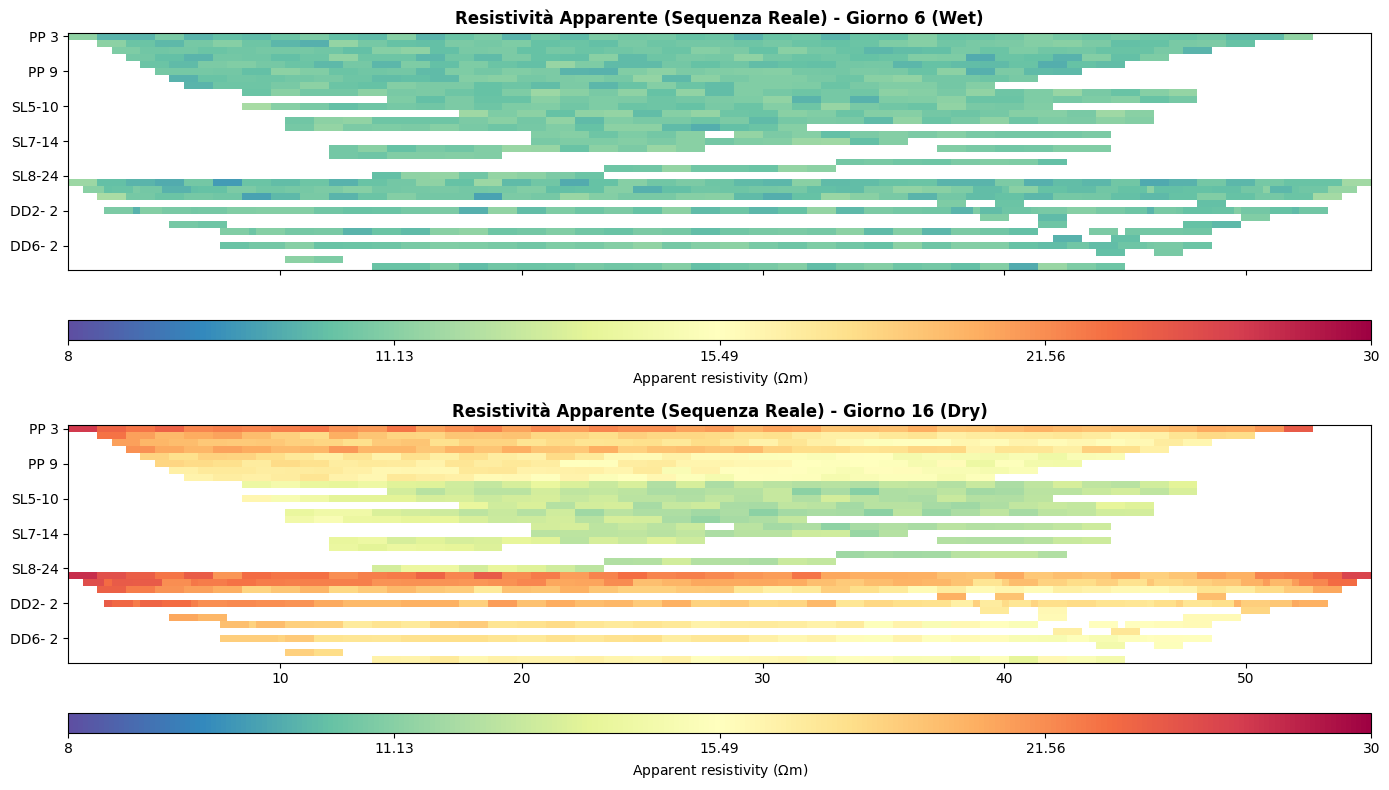

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 7 – Forward Modeling (L'Acquisizione Geofisica Virtuale Reale)
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
import pygimli.physics.ert as ert
import pandas as pd
from scipy.interpolate import griddata

print("1. Mapping dell'idrologia sulla mesh geofisica...")

# Coordinate centri cella Flopy
X_centers = np.zeros((nlay, ncol))
for i in range(nlay):
    X_centers[i, :] = x_arr[:-1] + (delr / 2.0)

# Appiattimento per interpolazione
xf_flat = X_centers.flatten()
zf_flat = Z_centers.flatten()
rho_wet_flat = rho_wet.flatten()
rho_dry_flat = rho_dry.flatten()

# Coordinate centri mesh PyGIMLi
cx = np.array([c.center().x() for c in mesh.cells()])
cz = np.array([c.center().y() for c in mesh.cells()])

points = np.vstack((xf_flat, zf_flat)).T
mesh_rho_wet = griddata(points, rho_wet_flat, (cx, cz), method='nearest')
mesh_rho_dry = griddata(points, rho_dry_flat, (cx, cz), method='nearest')

print("2. Caricamento sequenza reale e posizionamento elettrodi...")

# Carichiamo i sensori con la topografia dello slope
sensors = np.zeros((len(x_arr), 2))
sensors[:, 0] = x_arr
sensors[:, 1] = z_arr 

file_path = '2DDsup+MG+DDsup_rec.txt'

# Lettura robusta della sequenza
df_seq = pd.read_csv(file_path, skiprows=50, sep='\s+', names=['idx', 'A', 'B', 'M', 'N'])
df_seq = df_seq.apply(pd.to_numeric, errors='coerce').dropna()

# Creazione dello schema PyGIMLi
scheme = pg.DataContainerERT()
for s in sensors:
    scheme.createSensor(s)

# FIX FIRMA C++: Aggiungiamo l'indice della misura come primo argomento
for i, row in df_seq.iterrows():
    A, B = int(row['A']) - 1, int(row['B']) - 1
    M, N = int(row['M']) - 1, int(row['N']) - 1
    # La firma richiede: (indice_misura, A, B, M, N)
    scheme.createFourPointData(scheme.size(), A, B, M, N)

print(f"-> Sequenza reale caricata con successo: {scheme.size()} misure valide.")

print("3. Iniezione di corrente e simulazione del rumore (3%)...")
data_wet = ert.simulate(mesh, scheme=scheme, res=mesh_rho_wet, noiseLevel=0.03, noiseAbs=1e-4, seed=42)
data_dry = ert.simulate(mesh, scheme=scheme, res=mesh_rho_dry, noiseLevel=0.03, noiseAbs=1e-4, seed=42)

print("4. Generazione Pseudo-Sezioni con protocollo di campo...")
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

cMin, cMax = 8, 30 
ert.show(data_wet, ax=axs[0], cMin=cMin, cMax=cMax, cmap='Spectral')
axs[0].set_title("Resistività Apparente (Sequenza Reale) - Giorno 6 (Wet)", fontweight='bold')

ert.show(data_dry, ax=axs[1], cMin=cMin, cMax=cMax, cmap='Spectral')
axs[1].set_title("Resistività Apparente (Sequenza Reale) - Giorno 16 (Dry)", fontweight='bold')

plt.tight_layout()
plt.show()

26/04/26 - 12:06:09 - pyGIMLi - INFO - Found 2 regions.
26/04/26 - 12:06:09 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/04/26 - 12:06:09 - pyGIMLi - INFO - Found 2 regions.
26/04/26 - 12:06:09 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/04/26 - 12:06:09 - pyGIMLi - INFO - Creating forward mesh from region infos.
26/04/26 - 12:06:09 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
26/04/26 - 12:06:09 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1982 Cells: 3708 Boundaries: 2908
26/04/26 - 12:06:09 - pyGIMLi - INFO - Use median(data values)=10.699882734362617


1. Purificazione dei dati (Rimozione artefatti negativi)...
  Dati Wet validi: 1224
  Dati Dry validi: 1224
2. Inizializzazione del Manager di Inversione...
3. Inversione dataset Giorno 6 (Wet)... (Attendi)


26/04/26 - 12:06:12 - pyGIMLi - INFO - Found 2 regions.
26/04/26 - 12:06:12 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/04/26 - 12:06:12 - pyGIMLi - INFO - Found 2 regions.
26/04/26 - 12:06:12 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/04/26 - 12:06:12 - pyGIMLi - INFO - Creating forward mesh from region infos.
26/04/26 - 12:06:12 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
26/04/26 - 12:06:12 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1982 Cells: 3708 Boundaries: 2908
26/04/26 - 12:06:12 - pyGIMLi - INFO - Use median(data values)=16.941263694240128




4. Inversione dataset Giorno 16 (Dry)... (Attendi)


26/04/26 - 12:06:17 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
26/04/26 - 12:06:17 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 




5. Generazione Tomografie Ricostruite...


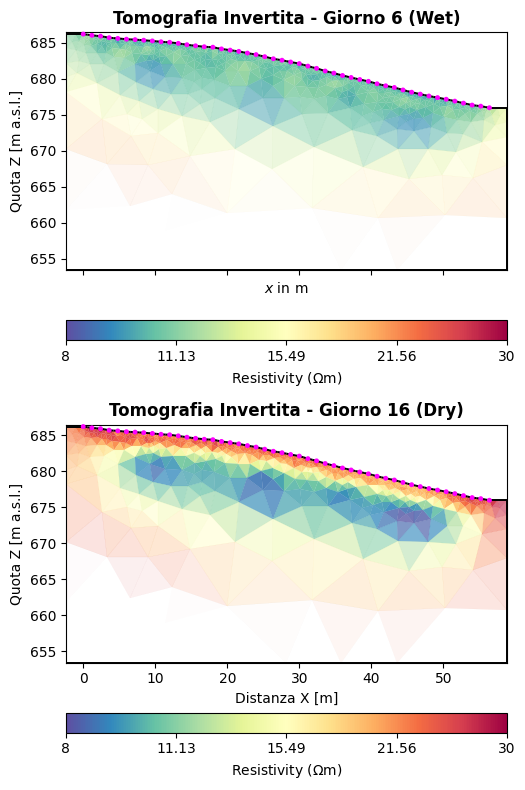

--- VERIFICA SENSORI DOPO INVERSIONE ---
Sensori a X = 8.0 m:
  -30 cm -> Wet: 10.3 | Dry: 22.9 ohm-m
  -80 cm -> Wet: 10.6 | Dry: 23.0 ohm-m
Sensori a X = 31.0 m:
  -30 cm -> Wet: 10.8 | Dry: 22.7 ohm-m
  -80 cm -> Wet: 10.6 | Dry: 20.9 ohm-m
Sensori a X = 51.0 m:
  -30 cm -> Wet: 10.6 | Dry: 22.5 ohm-m
  -80 cm -> Wet: 10.8 | Dry: 21.7 ohm-m


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 8 – L'Inversione Geofisica (Filtrata e Purificata)
# Obiettivo: Ricostruire il modello reale eliminando il rumore distruttivo
# ═══════════════════════════════════════════════════════════════════════════
import pygimli as pg
import matplotlib.pyplot as plt
import numpy as np

print("1. Purificazione dei dati (Rimozione artefatti negativi)...")
data_wet.remove(data_wet['rhoa'] <= 0)
data_dry.remove(data_dry['rhoa'] <= 0)
print(f"  Dati Wet validi: {data_wet.size()}")
print(f"  Dati Dry validi: {data_dry.size()}")

print("2. Inizializzazione del Manager di Inversione...")
mgr_wet = ert.ERTManager(data_wet)
mgr_dry = ert.ERTManager(data_dry)

print("3. Inversione dataset Giorno 6 (Wet)... (Attendi)")
inv_wet = mgr_wet.invert(lam=20, verbose=False)

print("4. Inversione dataset Giorno 16 (Dry)... (Attendi)")
inv_dry = mgr_dry.invert(lam=20, verbose=False)

print("5. Generazione Tomografie Ricostruite...")
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)

cMin, cMax = 8, 30

mgr_wet.showResult(ax=axs[0], cMin=cMin, cMax=cMax, cmap='Spectral_r')
axs[0].set_title('Tomografia Invertita - Giorno 6 (Wet)', fontweight='bold')
axs[0].set_ylabel('Quota Z [m a.s.l.]')

mgr_dry.showResult(ax=axs[1], cMin=cMin, cMax=cMax, cmap='Spectral_r')
axs[1].set_title('Tomografia Invertita - Giorno 16 (Dry)', fontweight='bold')
axs[1].set_xlabel('Distanza X [m]')
axs[1].set_ylabel('Quota Z [m a.s.l.]')

plt.tight_layout()
plt.show()

# Estrazione puntuale nei nodi dei sensori
print("--- VERIFICA SENSORI DOPO INVERSIONE ---")
target_x = [8.0, 31.0, 51.0]

for x in target_x:
    z_top = np.interp(x, x_arr, z_arr)
    pos_30 = [[x, z_top - 0.30]]
    pos_80 = [[x, z_top - 0.80]]
    
    res_w_30 = pg.interpolate(mgr_wet.paraDomain, inv_wet, pos_30)[0]
    res_d_30 = pg.interpolate(mgr_dry.paraDomain, inv_dry, pos_30)[0]
    res_w_80 = pg.interpolate(mgr_wet.paraDomain, inv_wet, pos_80)[0]
    res_d_80 = pg.interpolate(mgr_dry.paraDomain, inv_dry, pos_80)[0]
    
    print(f"Sensori a X = {x} m:")
    print(f"  -30 cm -> Wet: {res_w_30:.1f} | Dry: {res_d_30:.1f} ohm-m")
    print(f"  -80 cm -> Wet: {res_w_80:.1f} | Dry: {res_d_80:.1f} ohm-m")

<>:77: SyntaxWarning: invalid escape sequence '\O'
<>:80: SyntaxWarning: invalid escape sequence '\O'
<>:77: SyntaxWarning: invalid escape sequence '\O'
<>:80: SyntaxWarning: invalid escape sequence '\O'
C:\Users\luigi\AppData\Local\Temp\ipykernel_10452\2366669716.py:77: SyntaxWarning: invalid escape sequence '\O'
  pg.show(mgr.paraDomain, inv_results[idx_wet], ax=axs[0], cMin=8, cMax=15, label="Resistivity ($\Omega$m)")
C:\Users\luigi\AppData\Local\Temp\ipykernel_10452\2366669716.py:80: SyntaxWarning: invalid escape sequence '\O'
  pg.show(mgr.paraDomain, inv_results[idx_dry], ax=axs[1], cMin=8, cMax=15, label="Resistivity ($\Omega$m)")


Frame rilevati nel file binario HDS: 16

--- Inversione Time-Step 1/16 (kper=0, kstp=0) ---


26/04/26 - 12:14:29 - pyGIMLi - INFO - Data error estimate (min:max)  0.03003385443789161 : 0.0309634156278444
26/04/26 - 12:14:30 - pyGIMLi - INFO - Found 2 regions.
26/04/26 - 12:14:30 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/04/26 - 12:14:30 - pyGIMLi - INFO - Found 2 regions.
26/04/26 - 12:14:30 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/04/26 - 12:14:30 - pyGIMLi - INFO - Creating forward mesh from region infos.
26/04/26 - 12:14:30 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
26/04/26 - 12:14:30 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1982 Cells: 3708 Boundaries: 2908
26/04/26 - 12:14:30 - pyGIMLi - INFO - Use median(data values)=25.74997134200436





--- Inversione Time-Step 2/16 (kper=0, kstp=1) ---


26/04/26 - 12:16:12 - pyGIMLi - INFO - Data error estimate (min:max)  0.030077383933245813 : 0.032185130976275296
26/04/26 - 12:16:13 - pyGIMLi - INFO - Found 2 regions.
26/04/26 - 12:16:13 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/04/26 - 12:16:13 - pyGIMLi - INFO - Found 2 regions.
26/04/26 - 12:16:13 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/04/26 - 12:16:13 - pyGIMLi - INFO - Creating forward mesh from region infos.
26/04/26 - 12:16:13 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
26/04/26 - 12:16:13 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1982 Cells: 3708 Boundaries: 2908
26/04/26 - 12:16:13 - pyGIMLi - INFO - Use median(data values)=11.501102906445041


...

26/04/26 - 12:37:40 - pyGIMLi - INFO - Data error estimate (min:max)  0.030046524543112938 : 0.031485116448666105
26/04/26 - 12:37:40 - pyGIMLi - INFO - Found 2 regions.
26/04/26 - 12:37:40 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/04/26 - 12:37:40 - pyGIMLi - INFO - Found 2 regions.
26/04/26 - 12:37:40 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/04/26 - 12:37:40 - pyGIMLi - INFO - Creating forward mesh from region infos.
26/04/26 - 12:37:41 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
26/04/26 - 12:37:41 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1982 Cells: 3708 Boundaries: 2908
26/04/26 - 12:37:41 - pyGIMLi - INFO - Use median(data values)=16.60997802770362





--- Inversione Time-Step 15/16 (kper=8, kstp=2) ---


26/04/26 - 12:39:24 - pyGIMLi - INFO - Data error estimate (min:max)  0.030045850890121094 : 0.03147865435736549
26/04/26 - 12:39:24 - pyGIMLi - INFO - Found 2 regions.
26/04/26 - 12:39:24 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/04/26 - 12:39:24 - pyGIMLi - INFO - Found 2 regions.
26/04/26 - 12:39:24 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/04/26 - 12:39:24 - pyGIMLi - INFO - Creating forward mesh from region infos.
26/04/26 - 12:39:24 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
26/04/26 - 12:39:24 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1982 Cells: 3708 Boundaries: 2908
26/04/26 - 12:39:25 - pyGIMLi - INFO - Use median(data values)=16.688346809019812





--- Inversione Time-Step 16/16 (kper=9, kstp=2) ---


26/04/26 - 12:41:16 - pyGIMLi - INFO - Data error estimate (min:max)  0.030045244256066604 : 0.03147216233898111
26/04/26 - 12:41:16 - pyGIMLi - INFO - Found 2 regions.
26/04/26 - 12:41:16 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/04/26 - 12:41:16 - pyGIMLi - INFO - Found 2 regions.
26/04/26 - 12:41:16 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/04/26 - 12:41:16 - pyGIMLi - INFO - Creating forward mesh from region infos.
26/04/26 - 12:41:16 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
26/04/26 - 12:41:17 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1982 Cells: 3708 Boundaries: 2908
26/04/26 - 12:41:17 - pyGIMLi - INFO - Use median(data values)=16.95618748145816


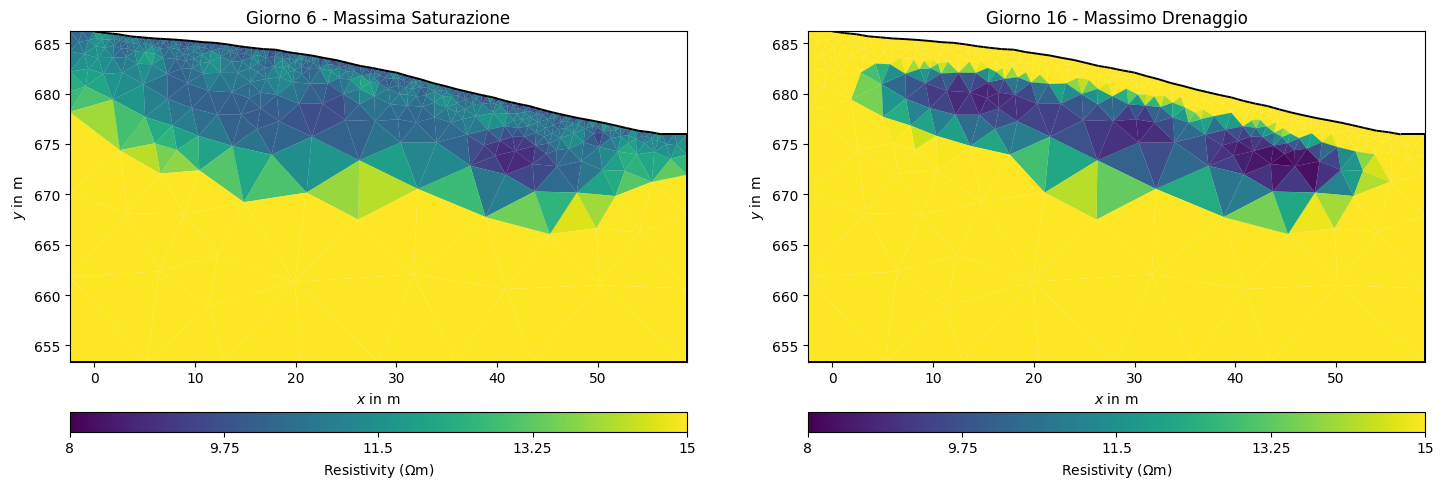

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 9 – L'Inversione Time-Lapse Sequenziale (La Prova della Verità)
# ═══════════════════════════════════════════════════════════════════════════
import os
import numpy as np
import pygimli as pg
from pygimli.physics import ert
import matplotlib.pyplot as plt
import flopy
from scipy.interpolate import NearestNDInterpolator

# ── 1. Lettura dinamica dell'intero transitorio ───────────────────────────
hds_file = os.path.join(workspace, 'hydro_transient.hds')
headobj = flopy.utils.HeadFile(hds_file)
times = headobj.get_kstpkper()
print(f"Frame rilevati nel file binario HDS: {len(times)}")

# ── 2. Petrofisica Sito-Specifico (HYPROP 2) ──────────────────────────────
def hyprop_resistivity(h, alpha, n, m, n_a, rho_sat):
    suction = np.where(h < 0, np.abs(h), 0.0)
    ec_norm = (1.0 + (alpha * suction)**n)**(-m * n_a)
    return rho_sat / ec_norm

# Preparazione coordinate per interpolazione spaziale (MODFLOW -> PyGIMLi)
# Assumo x_arr, Z_centers, nlay, ncol in memoria dalle celle precedenti
X_centers = (x_arr[:-1] + x_arr[1:]) / 2.0
X_grid, Z_grid = np.meshgrid(X_centers, np.zeros(nlay))
for i in range(nlay):
    Z_grid[i, :] = Z_centers[i, :]
modflow_points = np.column_stack((X_grid.ravel(), Z_grid.ravel()))

inv_results = []
starting_model = None 

# ── 3. L'Iteratore Time-Lapse ─────────────────────────────────────────────
for idx, kstpkper in enumerate(times):
    print(f"\n--- Inversione Time-Step {idx+1}/{len(times)} (kper={kstpkper[0]}, kstp={kstpkper[1]}) ---")
    
    # Estrazione dinamica e calcolo suzione
    head_current = headobj.get_data(kstpkper=kstpkper)[0, :, :]
    h_current = head_current - Z_centers
    
    # Applicazione Modello LAB diviso per layer
    rho_true = np.zeros_like(h_current)
    p_surf = {'alpha': 0.504, 'n': 1.239, 'm': 0.193, 'n_a': 3.460, 'rho_sat': 9.27}
    p_deep = {'alpha': 0.619, 'n': 1.236, 'm': 0.191, 'n_a': 5.068, 'rho_sat': 10.77}
    
    rho_true[0:2, :] = hyprop_resistivity(h_current[0:2, :], **p_surf)
    rho_true[2:, :] = hyprop_resistivity(h_current[2:, :], **p_deep)
    
    # Mappatura dalla griglia strutturata (MODFLOW) ai centri cella (PyGIMLi)
    interp = NearestNDInterpolator(modflow_points, rho_true.ravel())
    mesh_centers = np.column_stack((pg.x(mesh.cellCenters()), pg.y(mesh.cellCenters())))
    res_true_mesh = interp(mesh_centers)
    
    # Forward Modeling con iniezione di rumore al 3%
    data = ert.simulate(mesh, scheme=scheme, res=res_true_mesh, noiseLevel=0.03, noiseAbs=1e-4)
    
    # Filtro di sopravvivenza: via i negativi prima dell'inversione
    data.remove(data["rhoa"] <= 0)
    
    # Inversione vincolata al time-step precedente
    mgr = ert.ERTManager(data)
    inv_model = mgr.invert(startingModel=starting_model, verbose=False)
        
    starting_model = inv_model
    inv_results.append(inv_model)

# ── 4. Il Verdetto Fisico (Plot Giorno 6 vs 16) ──────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Se l'output ha 16 frame, questi indici prendono la fine dei primi due stress period
idx_wet = 5 
idx_dry = 15

# Usiamo la stessa scala (cMin, cMax) per esporre la reale entità della variazione
pg.show(mgr.paraDomain, inv_results[idx_wet], ax=axs[0], cMin=8, cMax=15, label="Resistivity ($\Omega$m)")
axs[0].set_title("Giorno 6 - Massima Saturazione")

pg.show(mgr.paraDomain, inv_results[idx_dry], ax=axs[1], cMin=8, cMax=15, label="Resistivity ($\Omega$m)")
axs[1].set_title("Giorno 16 - Massimo Drenaggio")

plt.tight_layout()
plt.show()

26/04/26 - 12:41:51 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
26/04/26 - 12:41:52 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
26/04/26 - 12:41:52 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
26/04/26 - 12:41:52 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
26/04/26 - 12:41:52 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
26/04/26 - 12:41:52 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
26/04/26 - 12:41:52 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
26/04/26 - 12:41:53 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
26/04/26 - 12:41:53 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' t

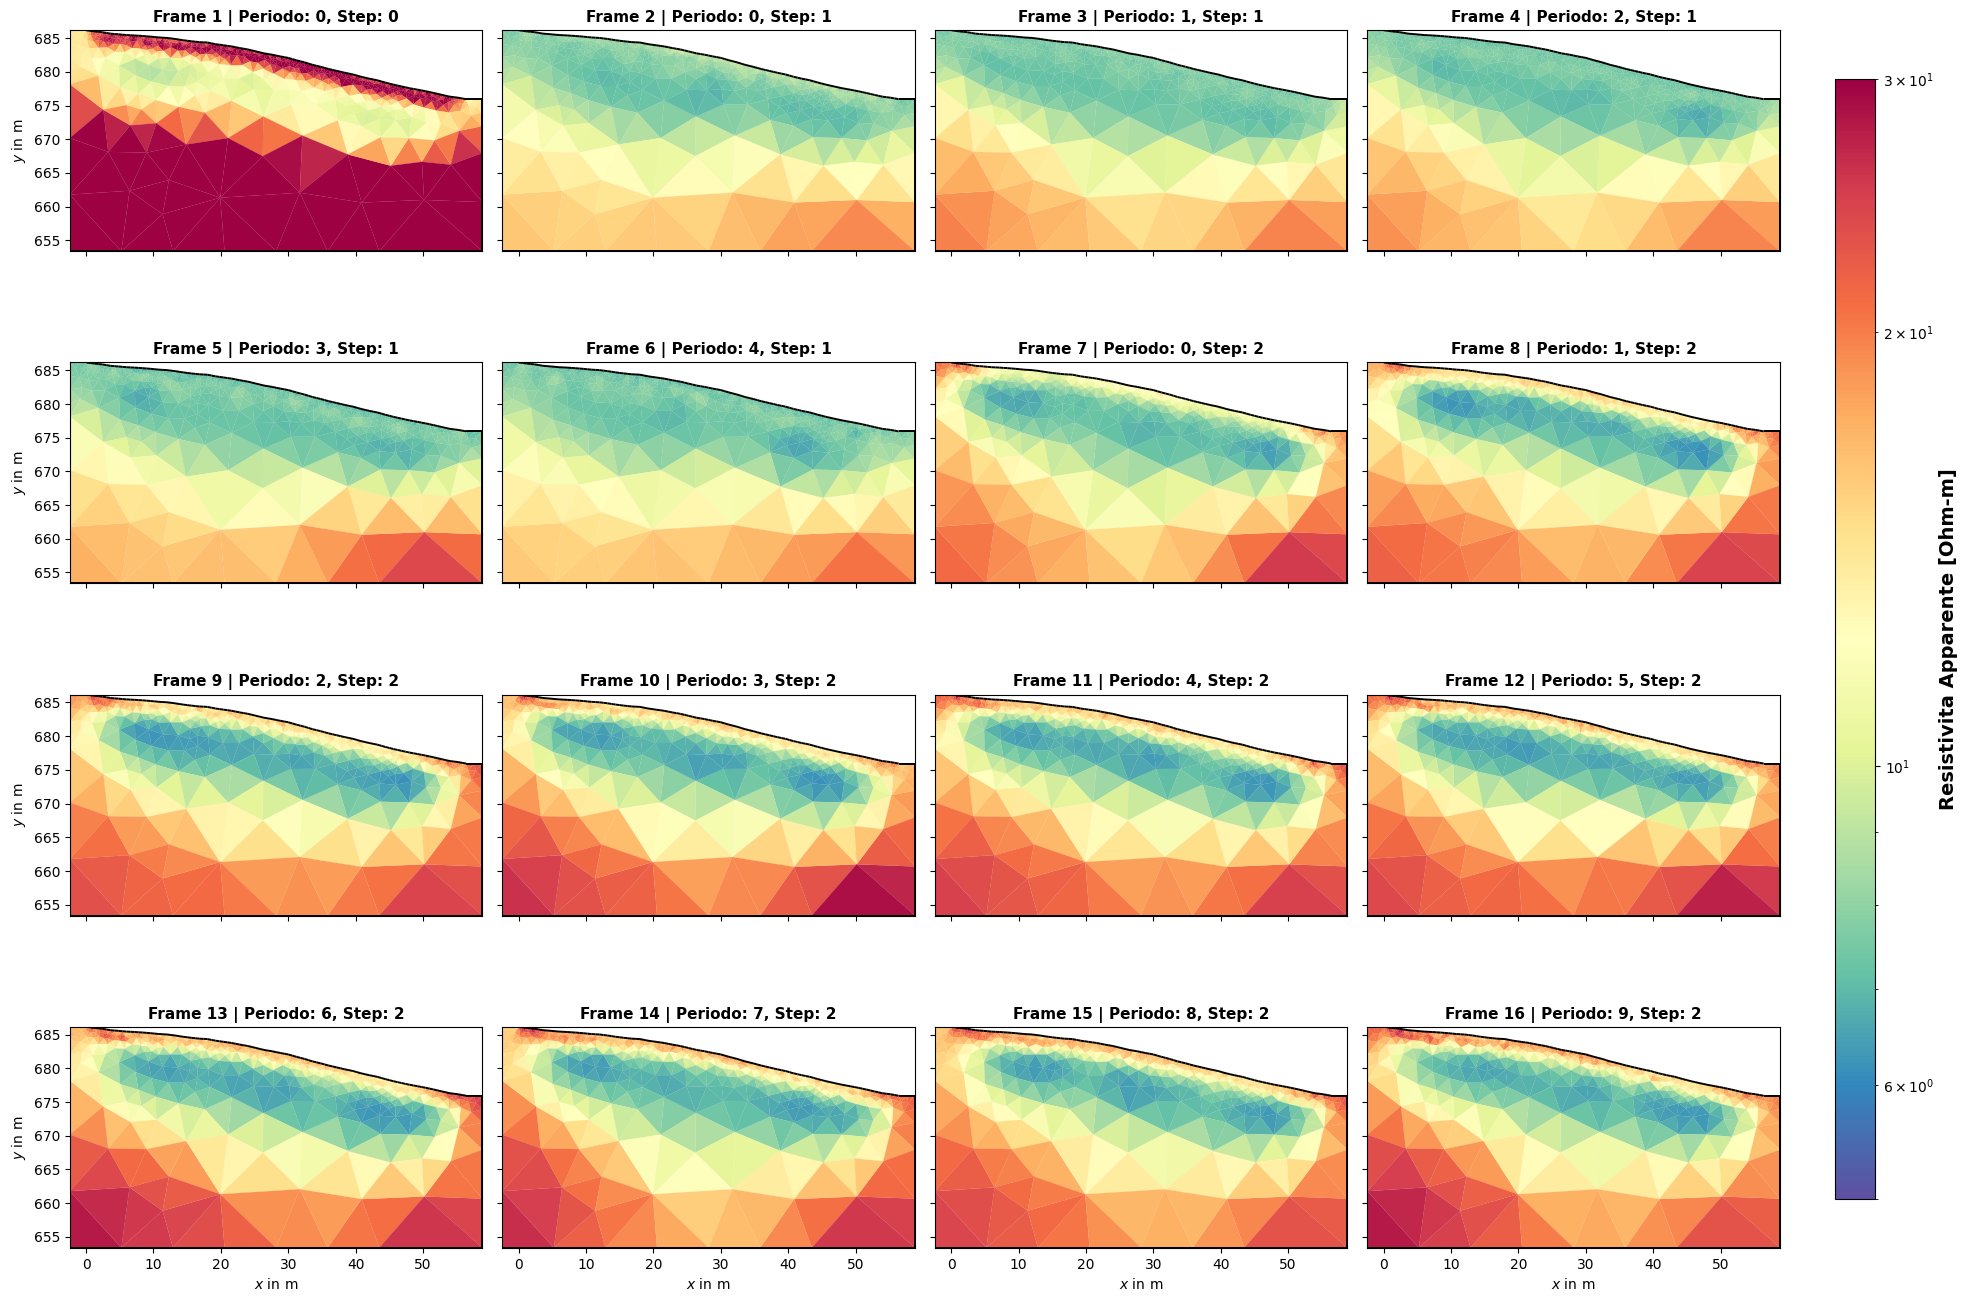

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 10 – Visualizzazione Cinematica (I 16 Frame del Transitorio)
# Obiettivo: Analizzare l'evoluzione temporale del fronte di essiccamento
# ═══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import pygimli as pg
import matplotlib.colors as mcolors

# --- IL TUO CRUSCOTTO DEL CONTRASTO ---
# Cambia questi valori per ricalibrare la scala dei colori in tutti i 16 plot
cMin_val = 5.0
cMax_val = 30.0

# Creazione dell'impalcatura visiva (Griglia 4x4)
fig, axes = plt.subplots(4, 4, figsize=(20, 16), sharex=True, sharey=True)
axes = axes.flatten()

# Ciclo di plottaggio sui 16 modelli invertiti
for i in range(len(inv_results)):
    ax = axes[i]
    
    # Disegna il tomogramma usando le tue variabili di controllo
    pg.show(mgr.paraDomain, inv_results[i], ax=ax, cMin=cMin_val, cMax=cMax_val, 
            colorBar=False, cmap='Spectral_r')
    
    # Estrai i metadati del tempo per il titolo
    kper, kstp = times[i]
    ax.set_title(f"Frame {i+1} | Periodo: {kper}, Step: {kstp}", fontsize=11, fontweight='bold')
    
    # Pulizia assi interni per leggibilità
    if i % 4 != 0:
        ax.set_ylabel("")
    if i < 12:
        ax.set_xlabel("")

# Disattivare eventuali assi vuoti se i frame fossero meno di 16 (non è il tuo caso, ma è codice robusto)
for j in range(len(inv_results), len(axes)):
    axes[j].axis('off')

# Costruzione di una colorbar unificata globale sulla destra
sm = plt.cm.ScalarMappable(cmap='Spectral_r', norm=mcolors.LogNorm(vmin=cMin_val, vmax=cMax_val))
sm._A = [] 
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Resistivita Apparente [Ohm-m]', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

26/04/26 - 12:43:00 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


Generazione di 16 plot individuali in corso...


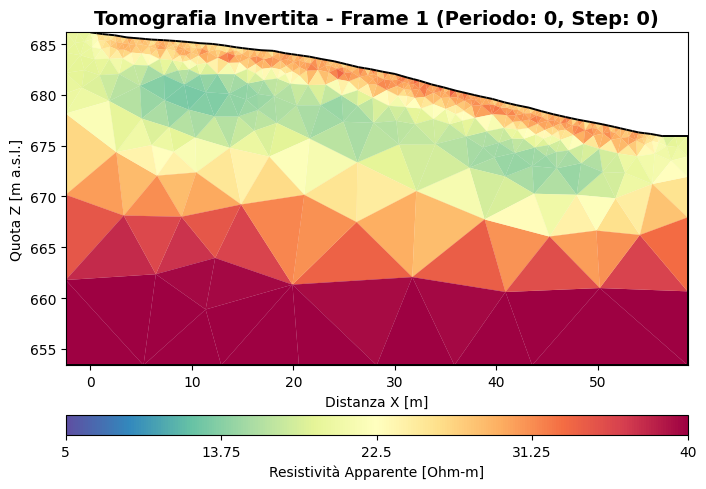

26/04/26 - 12:43:00 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


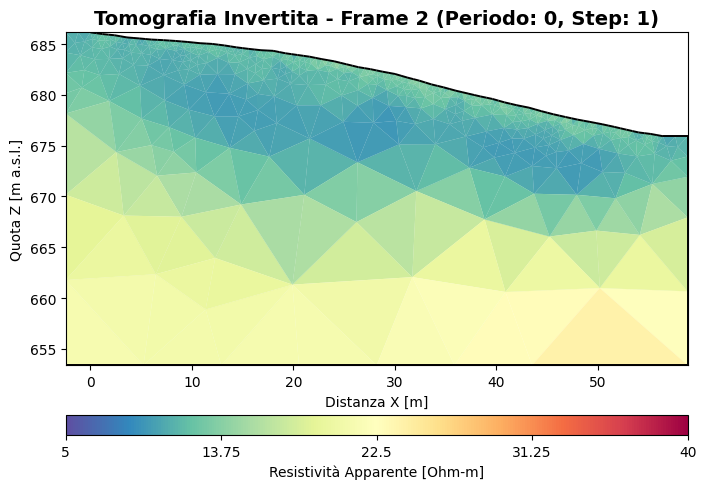

26/04/26 - 12:43:00 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


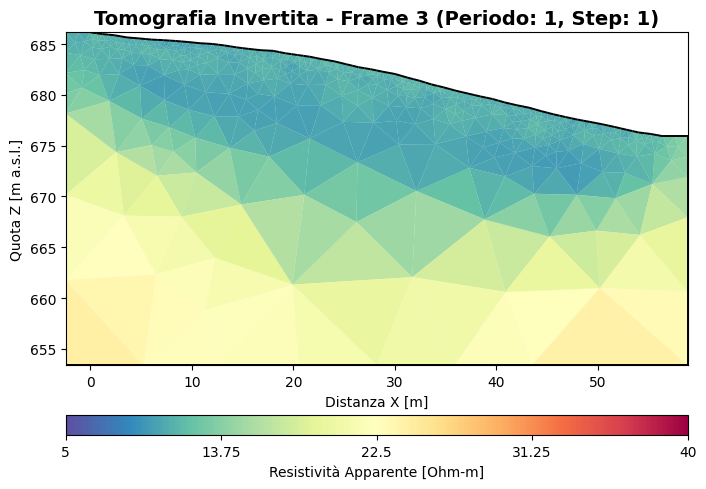

26/04/26 - 12:43:00 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


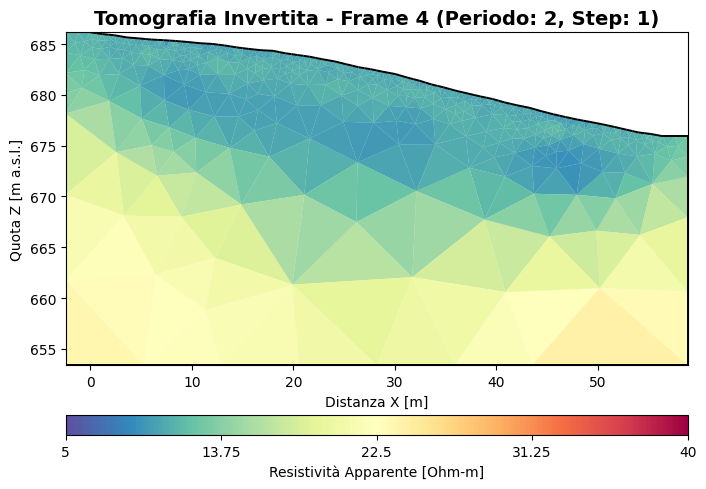

26/04/26 - 12:43:00 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


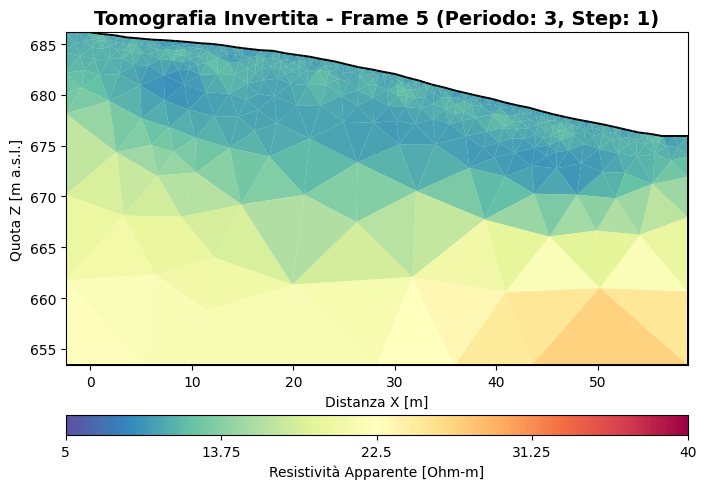

26/04/26 - 12:43:00 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


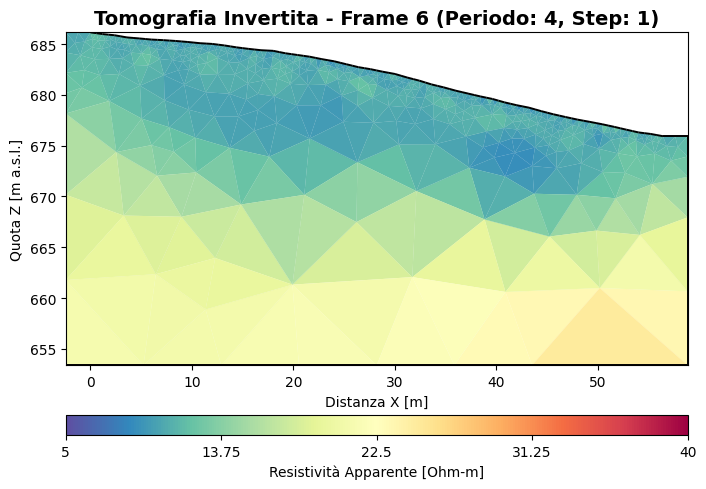

26/04/26 - 12:43:00 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


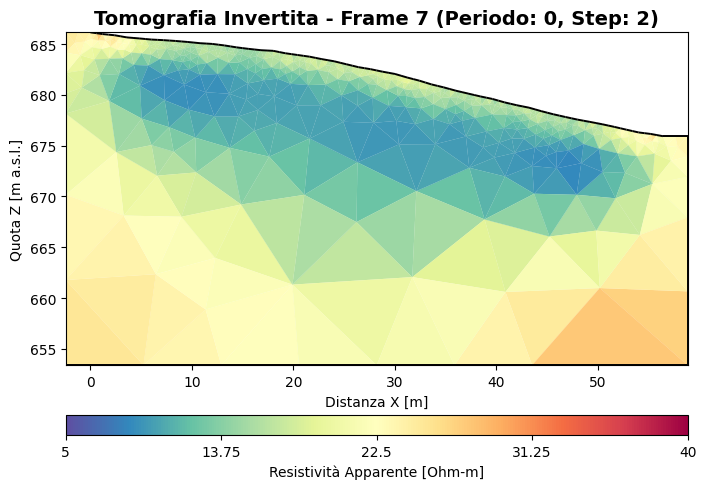

26/04/26 - 12:43:01 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


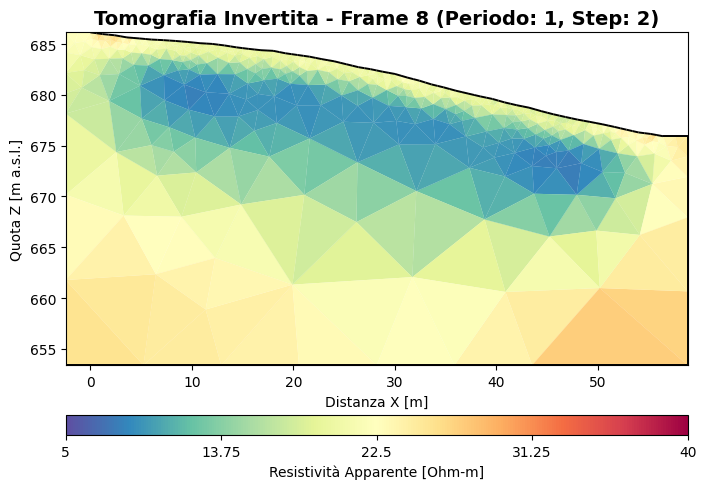

26/04/26 - 12:43:01 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


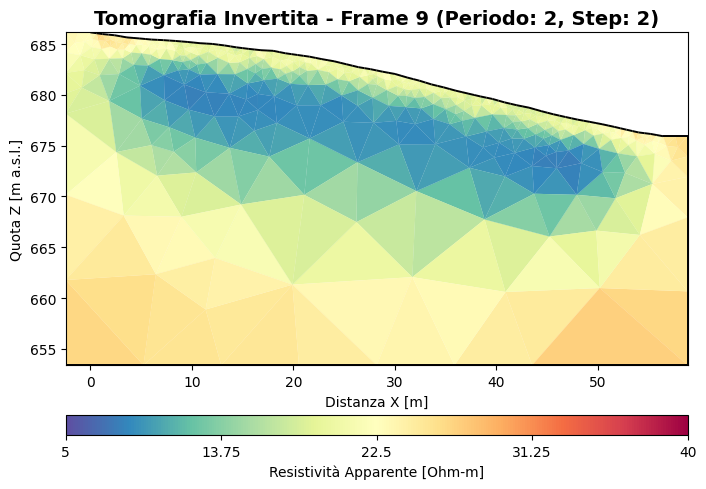

26/04/26 - 12:43:01 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


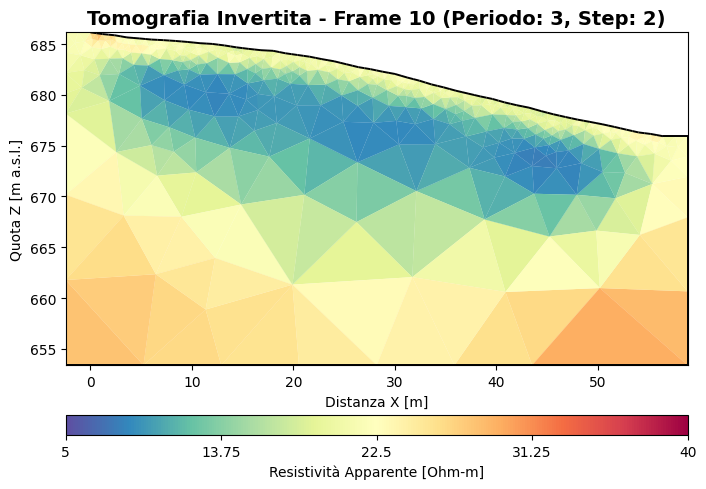

26/04/26 - 12:43:01 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


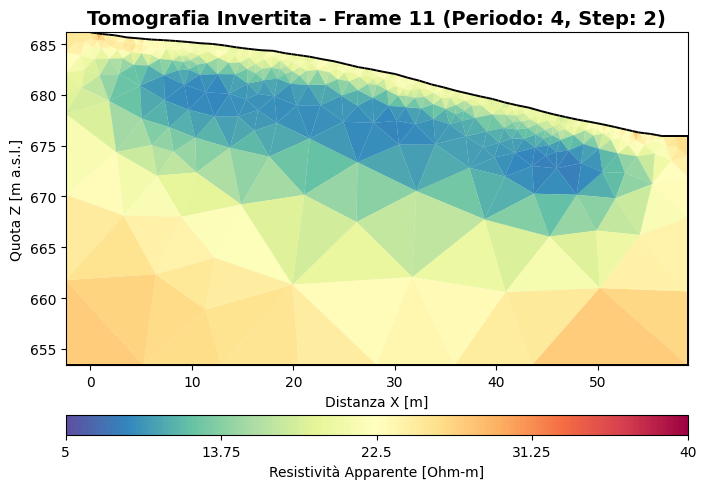

26/04/26 - 12:43:01 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


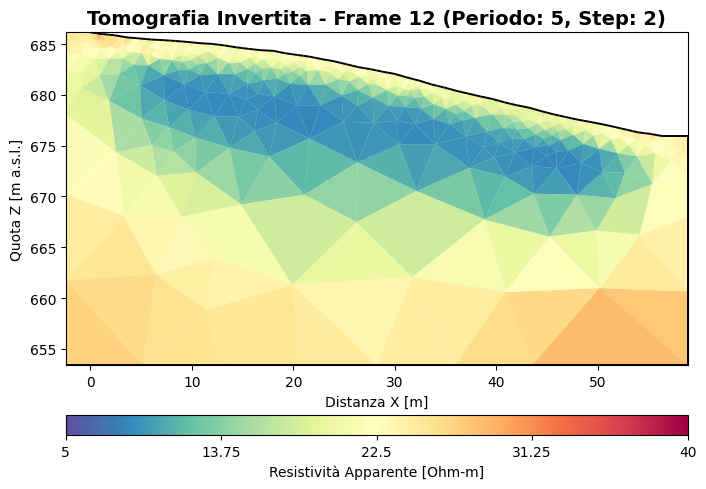

26/04/26 - 12:43:01 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


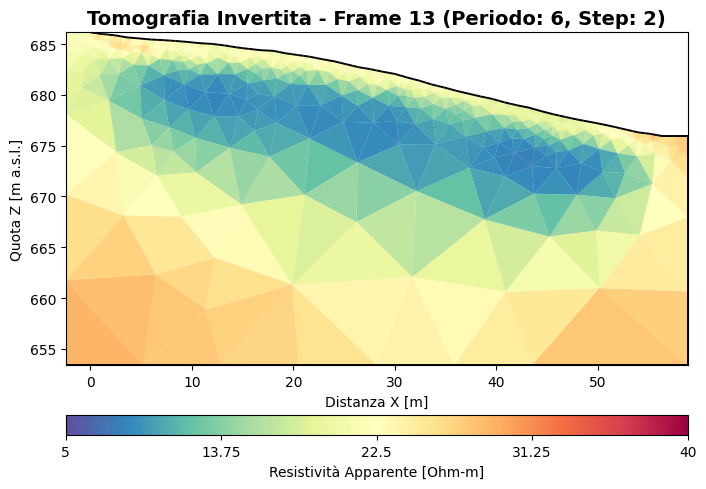

26/04/26 - 12:43:02 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


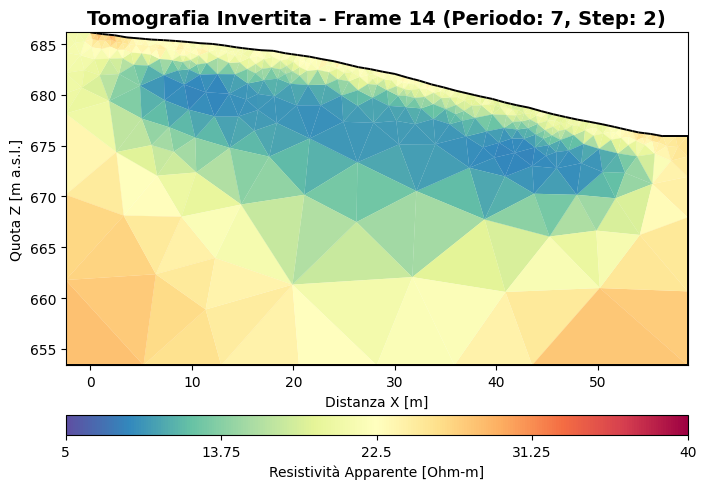

26/04/26 - 12:43:02 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


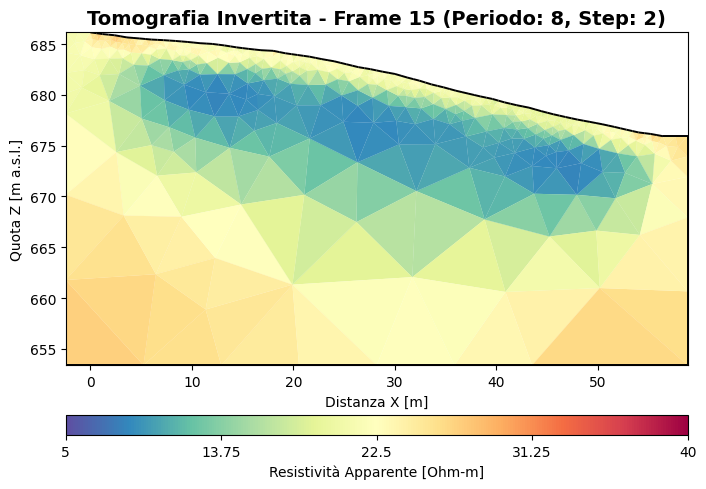

26/04/26 - 12:43:02 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


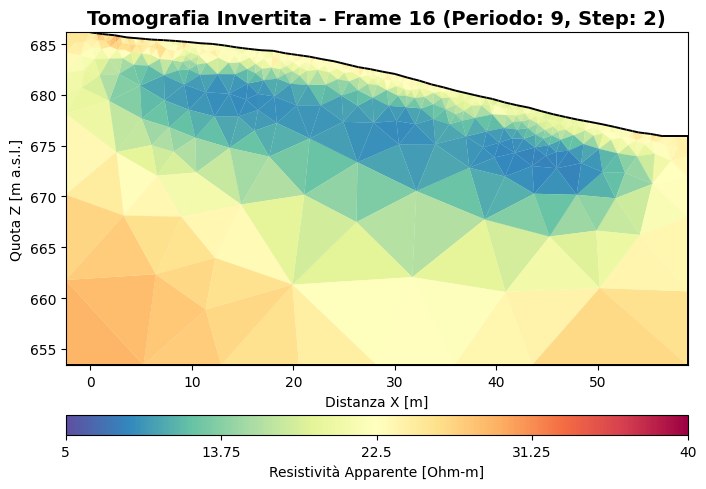

Estrazione completata.


In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 11 – Analisi Dettagliata (Plot Singoli per Frame)
# Obiettivo: Esplodere l'array temporale per ispezione ad alta risoluzione
# ═══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import pygimli as pg

# I controlli della dinamica visiva
cMin_val = 5.0
cMax_val = 40.0

print(f"Generazione di {len(inv_results)} plot individuali in corso...")

for i in range(len(inv_results)):
    # Creazione di una figura singola, larga e schiacciata per rispettare la topografia
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Render del tomogramma
    pg.show(mgr.paraDomain, inv_results[i], ax=ax, cMin=cMin_val, cMax=cMax_val, 
            cmap='Spectral_r', colorBar=True, label='Resistività Apparente [Ohm-m]')
    
    # Titolazione dinamica
    kper, kstp = times[i]
    ax.set_title(f"Tomografia Invertita - Frame {i+1} (Periodo: {kper}, Step: {kstp})", 
                 fontsize=14, fontweight='bold')
    
    ax.set_xlabel('Distanza X [m]')
    ax.set_ylabel('Quota Z [m a.s.l.]')
    
    plt.tight_layout()
    plt.show()

print("Estrazione completata.")

26/04/26 - 12:45:55 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


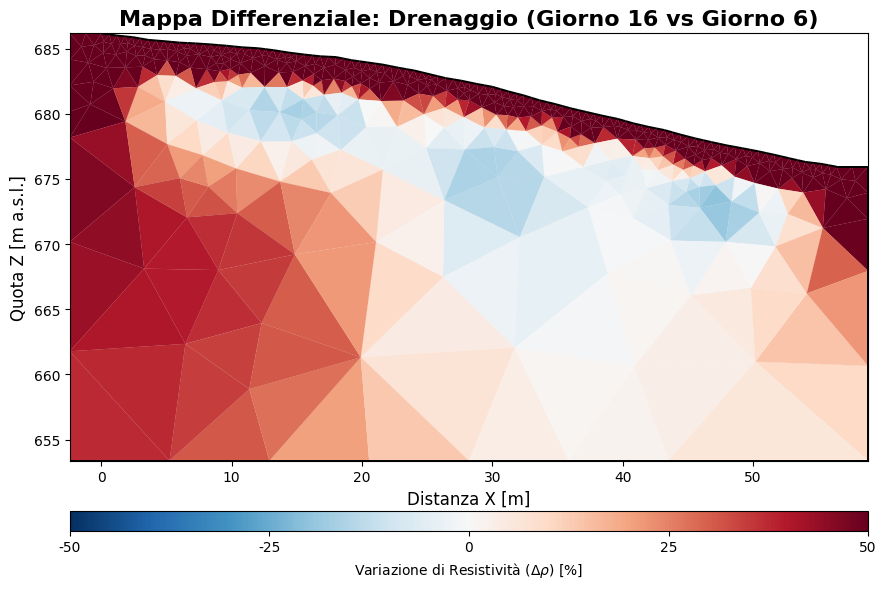

--- VERITÀ MATEMATICA DEL SEGNALE ---
Variazione massima positiva (Essiccamento): +174.5%
Variazione massima negativa (Saturazione anomala): -20.1%
Variazione media assoluta sul dominio: 68.7%


In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 12 – Analisi Differenziale (Delta Percentuale)
# Obiettivo: Isolare il movimento dell'acqua annullando la geologia di base
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg

# Identifichiamo i fotogrammi chiave (Indici Python: 0-based)
idx_wet = 5   # Frame 6 (Fine pioggia)
idx_dry = 15  # Frame 16 (Fine drenaggio)

# Estrazione dei vettori di resistività
res_wet = np.array(inv_results[idx_wet])
res_dry = np.array(inv_results[idx_dry])

# Calcolo del Delta Resistività Percentuale
# (Dry - Wet) / Wet * 100
delta_percent = ((res_dry - res_wet) / res_wet) * 100.0

# ── Visualizzazione dell'Anomalia ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Usiamo una mappa colori divergente (Rosso = aumento resistività/essiccamento, Blu = diminuzione/bagnato)
# Fissiamo i limiti simmetrici per centrare il bianco sullo zero
limit = 50.0 # +/- 50% di variazione

pg.show(mgr.paraDomain, delta_percent, ax=ax, cmap='RdBu_r', 
        cMin=-limit, cMax=limit, label=r'Variazione di Resistività ($\Delta\rho$) [%]')

ax.set_title(f"Mappa Differenziale: Drenaggio (Giorno 16 vs Giorno 6)", fontsize=16, fontweight='bold')
ax.set_xlabel('Distanza X [m]', fontsize=12)
ax.set_ylabel('Quota Z [m a.s.l.]', fontsize=12)

plt.tight_layout()
plt.show()

# Quantificazione cruda
print("--- VERITÀ MATEMATICA DEL SEGNALE ---")
print(f"Variazione massima positiva (Essiccamento): +{np.max(delta_percent):.1f}%")
print(f"Variazione massima negativa (Saturazione anomala): {np.min(delta_percent):.1f}%")
print(f"Variazione media assoluta sul dominio: {np.mean(np.abs(delta_percent)):.1f}%")